# A -  SDM model + beta & theta & rho + impacts

In [ ]:
import os
import geopandas as gpd
import numpy as np
import libpysal
from spreg import ML_Lag
from libpysal.weights import DistanceBand, lag_spatial
import re
import pandas as pd 
# -----------------------------
# 设置路径
# -----------------------------
grid_folder = r"E:\seoul\480_based"
output_folder = os.path.join(grid_folder, 'statistics')
os.makedirs(output_folder, exist_ok=True)

# -----------------------------
# 准备变量
# -----------------------------
year = 2016
for year in [2016,2023]:
    target_vars = [f'nor_{year}', f'ext_{year}', f'hr_{year}']
    explanatory_vars = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
    explanatory_vars_clean = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR']
    grid_folder = r'E:\seoul\480_based'
    output_file = r'E:\seoul\480_based\statistics\SDM_effects.xlsx'
    def star(p):
        return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else '.' if p < 0.1 else ''

    # 使用 ExcelWriter，mode='a' 可以追加 sheet（如果文件存在）
    with pd.ExcelWriter(output_file, engine='openpyxl', mode='a' if os.path.exists(output_file) else 'w',
                        if_sheet_exists='replace') as writer:

        for filename in os.listdir(grid_folder):
            if filename.endswith(f'city{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp'):
                path = os.path.join(grid_folder, filename)
                gdf = gpd.read_file(path)
                gdf = gdf.replace([np.inf, -np.inf], np.nan)

                for target in target_vars:
                    if target not in gdf.columns:
                        continue

                    # 只保留完整数据
                    data = gdf[explanatory_vars + [target]].dropna()
                    data_gdf = gdf.loc[data.index].reset_index(drop=True)

                    threshold = 1000
                    w = DistanceBand.from_dataframe(data_gdf, threshold=threshold, binary=False)
                    w.transform = 'r'  # 行标准化
                    
                    # 找孤岛
                    row_sums = w.full()[0].sum(axis=1)
                    islands = np.where(row_sums == 0)[0]

                    # 删除孤岛
                    data_gdf = data_gdf.drop(data_gdf.index[islands]).reset_index(drop=True)
                    data = data_gdf[explanatory_vars + [target]]

                    # 再生成 W
                    w = DistanceBand.from_dataframe(data_gdf, threshold=threshold, binary=False)
                    w.transform = 'r'
                    W = np.array(w.full()[0])  # 稠密矩阵
                    # print(data.shape)
                    
                    # -----------------------------
                    # y 与 X
                    # -----------------------------
                    yi = data[target].values.reshape(-1, 1)
                    X_main = data[explanatory_vars].values
                    X_all = X_main.copy()
                    name_x = explanatory_vars

                    # -----------------------------
                    # SDM 模型估计
                    # -----------------------------
                    slx_vars_bool = [v in explanatory_vars_clean for v in explanatory_vars]
                    model_sdm = ML_Lag(
                        yi, X_all, w=w, slx_lags=1, slx_vars=slx_vars_bool, # type: ignore
                        name_y=target, name_x=name_x,
                        name_w=f"W{threshold}", name_ds=f"yr{year}",
                        spat_diag=True, spat_impacts=['full'] # type: ignore
                    )

                    coefs = model_sdm.betas.flatten()
                    vars_ = model_sdm.name_x
                    print(model_sdm.rho)
                    print(coefs)
                    print(vars_)

                    # ==================================================
                    summary_str = str(model_sdm.summary)
                    lines = summary_str.split("\n")
                    impacts_data = []
                    capture = False
                    for line in lines:
                        if "SPATIAL DURBIN MODEL IMPACTS" in line:
                            capture = True
                            continue
                        if capture:
                            if not line.strip():  # 遇到空行就停
                                break
                            # 跳过分隔线和表头
                            if "Direct" in line and "Indirect" in line and "Total" in line:
                                continue
                            if set(line.strip()) == {"-"}:  # 全是横线
                                continue
                            parts = re.split(r"\s+", line.strip())
                            if len(parts) == 4:
                                var, direct, indirect, total = parts
                                impacts_data.append([var, float(direct), float(indirect), float(total)])

                    df_impacts = pd.DataFrame(impacts_data, columns=["Variable","Direct","Indirect","Total"])
                    print(df_impacts)

                    # # # 👉 保存 Excel
                    # # 保存到 Excel，不同 target 用 sheet 名
                    # sheet_name = target
                    # df_impacts.to_excel(writer, sheet_name=sheet_name, index=False)
                    # print(f"Saved sheet: {sheet_name}")


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(
c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There

('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')
0.8072854646766524
[ 5.34139801e+00  2.31185238e-02  2.35408343e-03  8.19999367e+00
 -2.04865060e+01 -1.19001171e-02 -1.10520656e-01 -2.18909693e-03
 -2.27810148e-02 -7.67982622e-04 -3.35631643e-02 -5.10919265e-03
 -5.42014056e+00  1.21644566e+01  1.11030102e-02  7.39047500e-02
  8.07285465e-01]
['CONSTANT', 'BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M', 'W_BCR', 'W_BHV', 'W_SVF', 'W_NDVI', 'W_EV', 'W_WR', 'W_nor_2016']
  Variable   Direct  Indirect    Total
0      BCR   0.0271   -0.0813  -0.0542
1      BHV   0.0028   -0.0171  -0.0143
2      SVF   9.6202    4.8045  14.4247
3     NDVI -24.0346  -19.1487 -43.1833
4       EV  -0.0140    0.0098  -0.0041
5     

c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(
c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There

0.8312008569651662
[ 5.83366216e+00  3.49886129e-02 -4.78159637e-03  8.47960682e+00
 -3.79778400e+01 -1.53055322e-02 -1.85083816e-01 -3.84876075e-02
 -2.13643372e-02 -2.08332260e-02 -3.64634334e-02  1.49721492e-02
 -5.00835795e+00  2.85245325e+01  1.45156569e-02  1.40520590e-01
  8.31200857e-01]
['CONSTANT', 'BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M', 'W_BCR', 'W_BHV', 'W_SVF', 'W_NDVI', 'W_EV', 'W_WR', 'W_ext_2016']
  Variable   Direct  Indirect    Total
0      BCR   0.0419   -0.0506  -0.0087
1      BHV  -0.0057    0.0661   0.0604
2      SVF  10.1506   10.4138  20.5644
3     NDVI -45.4617  -10.5416 -56.0033
4       EV  -0.0183    0.0136  -0.0047
5       WR  -0.2216   -0.0424  -0.2640
6   Dist_W  -0.0461   -0.1819  -0.2280
7   Dist_P  -0.0256   -0.1010  -0.1266
8   Dist_M  -0.0249   -0.0985  -0.1234
('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARN

c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(
c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There

...

('WARNING: ', 1392, ' is an island (no neighbors)')
('WARNING: ', 1571, ' is an island (no neighbors)')
0.8168529790343809
[ 6.27927231e+00  2.69041008e-02  2.64832392e-03  7.63611029e+00
 -2.74251930e+01 -1.25178616e-02 -1.72305724e-01 -4.97572245e-02
 -4.47621236e-02  6.93864345e-03 -1.87388125e-02  3.40932378e-03
 -5.45945506e+00  2.20319991e+01  9.78882985e-03  1.32278543e-01
  8.16852979e-01]
['CONSTANT', 'BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M', 'W_BCR', 'W_BHV', 'W_SVF', 'W_NDVI', 'W_EV', 'W_WR', 'W_nor_2023']
  Variable   Direct  Indirect    Total
0      BCR   0.0324    0.0122   0.0446
1      BHV   0.0032    0.0299   0.0331
2      SVF   9.1857    2.6990  11.8847
3     NDVI -32.9906    3.5432 -29.4473
4       EV  -0.0151    0.0002  -0.0149
5       WR  -0.2073   -0.0113  -0.2186
6   Dist_W  -0.0599   -0.2118  -0.2717
7   Dist_P  -0.0538   -0.1906  -0.2444
8   Dist_M   0.0083    0.0295   0.0379
('WARNING: ', 1392, ' is an island (no neighbors)')
('WARN

c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  W.__init__(
c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 5 disconnected components.
  w = W(neighbors,

0.8950130450037691
[ 3.31934617e+00  2.37417006e-02 -3.12900617e-03  8.03856948e+00
 -2.90216364e+01 -1.24875929e-02 -1.72092176e-01 -1.83601036e-02
 -2.69255956e-02 -1.28470519e-02 -9.09346129e-03  1.62921055e-02
 -6.22028817e+00  2.60097943e+01  1.15582546e-02  1.49724396e-01
  8.95013045e-01]
['CONSTANT', 'BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M', 'W_BCR', 'W_BHV', 'W_SVF', 'W_NDVI', 'W_EV', 'W_WR', 'W_ext_2023']
  Variable   Direct  Indirect    Total
0      BCR   0.0316    0.1079   0.1395
1      BHV  -0.0042    0.1295   0.1254
2      SVF  10.6946    6.6245  17.3191
3     NDVI -38.6106    9.9229 -28.6878
4       EV  -0.0166    0.0078  -0.0089
5       WR  -0.2290    0.0159  -0.2131
6   Dist_W  -0.0244   -0.1505  -0.1749
7   Dist_P  -0.0358   -0.2206  -0.2565
8   Dist_M  -0.0171   -0.1053  -0.1224
('WARNING: ', 1392, ' is an island (no neighbors)')
('WARNING: ', 1571, ' is an island (no neighbors)')


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  W.__init__(
c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 5 disconnected components.
  w = W(neighbors,

0.9470790028591128
[ 6.74540684e-03  2.48419789e-03  5.69467692e-03 -4.68928178e-01
  1.51040069e+00 -6.52165993e-05  5.28637619e-04 -1.02211224e-02
 -1.69244623e-03  9.20399832e-03 -7.33894820e-03 -9.65372111e-03
  3.74479936e-01 -1.64832424e+00 -1.82409854e-04 -2.14997572e-03
  9.47079003e-01]
['CONSTANT', 'BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M', 'W_BCR', 'W_BHV', 'W_SVF', 'W_NDVI', 'W_EV', 'W_WR', 'W_hr_2023']
  Variable  Direct  Indirect   Total
0      BCR  0.0038   -0.0955 -0.0917
1      BHV  0.0087   -0.0835 -0.0748
2      SVF -0.7186   -1.0661 -1.7847
3     NDVI  2.3145   -4.9208 -2.6062
4       EV -0.0001   -0.0046 -0.0047
5       WR  0.0008   -0.0314 -0.0306
6   Dist_W -0.0157   -0.1775 -0.1931
7   Dist_P -0.0026   -0.0294 -0.0320
8   Dist_M  0.0141    0.1598  0.1739


# ** 如果不做isolation 清理的 vars_值结果

In [ ]:
import os
import geopandas as gpd
import numpy as np
import libpysal
from spreg import ML_Lag
from libpysal.weights import DistanceBand, lag_spatial

# -----------------------------
# 设置路径
# -----------------------------
grid_folder = r"E:\seoul\480_based"
output_folder = os.path.join(grid_folder, 'statistics')
os.makedirs(output_folder, exist_ok=True)

# -----------------------------
# 准备变量
# -----------------------------
year = 2016
target_vars = [f'nor_{year}', f'ext_{year}', f'hr_{year}']
explanatory_vars = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
explanatory_vars_clean = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR']

for filename in os.listdir(grid_folder):
    if filename.endswith(f'city{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'):
        path = os.path.join(grid_folder, filename)
        gdf = gpd.read_file(path)
        gdf = gdf.replace([np.inf, -np.inf], np.nan)

        for target in target_vars:
            if target not in gdf.columns:
                continue

            # 只保留完整数据
            data = gdf[explanatory_vars + [target]].dropna()
            data_gdf = gdf.loc[data.index].reset_index(drop=True)

            threshold = 1000
            w = DistanceBand.from_dataframe(data_gdf, threshold=threshold, binary=False)
            w.transform = 'r'  # 行标准化

            # -----------------------------
            # y 与 X
            # -----------------------------
            yi = data[target].values.reshape(-1, 1)
            X_main = data[explanatory_vars].values
            X_all = X_main.copy()
            name_x = explanatory_vars

            # -----------------------------
            # SDM 模型估计
            # -----------------------------
            slx_vars_bool = [v in explanatory_vars_clean for v in explanatory_vars]
            model_sdm = ML_Lag(
                yi, X_all, w=w, slx_lags=1, slx_vars=slx_vars_bool,
                name_y=target, name_x=name_x,
                name_w=f"W{threshold}", name_ds=f"yr{year}",
                spat_diag=True, spat_impacts=['full']
            )

            # -----------------------------
            # 预测
            # -----------------------------
            # 获取模型系数
            coefs = model_sdm.betas.flatten()
            coef_dict = dict(zip(model_sdm.name_x, coefs))
            constant = coef_dict.get('CONSTANT', 0.0)
            rho = getattr(model_sdm, 'rho', 0.0)

            beta = np.array([coef_dict[v] for v in explanatory_vars])
            theta = np.array([coef_dict[f"W_{v}"] for v in explanatory_vars_clean])

            # 构造 WX_clean
            WX_clean = lag_spatial(w, data[explanatory_vars_clean].values)

            # I - rho*W
            I = np.eye(len(X_main))
            W_dense = np.array(w.full()[0])
            y_final = np.linalg.inv(I - rho * W_dense) @ (constant + X_main @ beta + WX_clean @ theta)

            print(f"\n===== {filename} | Target: {target} =====")
            print("模型系数:", coef_dict)
            print("rho:", rho)
            predy = model_sdm.predy
            
            # print("预测 y_final min/mean/max:", y_final.min(), y_final.mean(), y_final.max())
            # print("predy y_final min/mean/max:", predy.min(), predy.mean(), predy.max())
            # diff = y_final.flatten() - predy.flatten()
            # print("差值 min/mean/max:", diff.min(), diff.mean(), diff.max())
            # mismatch_idx = np.where(np.abs(diff) > 1e-8)[0]
            # print("有差异的行数:", len(mismatch_idx))
            # for i in mismatch_idx[:10]:
            #     print(f"row {i}: formula ={y_final[i]}, predy ={predy[i]}, difference ={diff[i]}")

c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(


('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')

===== city2016_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp | Target: nor_2016 =====
模型系数: {'CONSTANT': 23.28546296551063, 'BCR': 0.033750362485525334, 'BHV': 0.012842780685790756, 'SVF': 10.900458433729131, 'NDVI': -20.08747031731854, 'EV': -0.01227802345339884, 'WR': -0.11022584799992023, 'Dist_W': -0.008583841593831416, 'Dist_P': -0.0056361232249308515, 'Dist_M': -0.02276362274207392, 'W_BCR': -0.11001912569826183, 'W_BHV': -0.10208497366754578, 'W_SVF': -16.477582718244754, 'W_NDVI': 2.6953915852699737, 'W_EV': 0.0049630314654840165, 'W_WR': 0.033156182337370305, 'W_nor_2016': 0.5825572252491803}
rho: 0.5825572252491803
('WARNING: ', 1308, ' is an i

c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(



===== city2016_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp | Target: ext_2016 =====
模型系数: {'CONSTANT': 33.012579924338525, 'BCR': 0.052030837526050415, 'BHV': 0.011751590438778861, 'SVF': 12.59195107456264, 'NDVI': -37.39640501835659, 'EV': -0.015399417171391034, 'WR': -0.18500464656479396, 'Dist_W': -0.08491394634562077, 'Dist_P': -0.0030189396720138213, 'Dist_M': -0.08278907945376482, 'W_BCR': -0.13964130894686572, 'W_BHV': -0.11999060675951359, 'W_SVF': -21.729585725007922, 'W_NDVI': 14.029398255217288, 'W_EV': 0.004659303656916449, 'W_WR': 0.07581097008782499, 'W_ext_2016': 0.5724614359359316}
rho: 0.5724614359359316
('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(



===== city2016_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp | Target: hr_2016 =====
模型系数: {'CONSTANT': -9.15315488624594, 'BCR': -0.019715326121036075, 'BHV': 0.000337478822241962, 'SVF': -1.9617254443105199, 'NDVI': 17.056405877836866, 'EV': 0.003224712631559097, 'WR': 0.07339761887377518, 'Dist_W': 0.040683793281491076, 'Dist_P': -0.004977405651486562, 'Dist_M': 0.04088703055468497, 'W_BCR': 0.05467520145980766, 'W_BHV': 0.04563304387558499, 'W_SVF': 8.556372623267702, 'W_NDVI': -13.94858737659616, 'W_EV': 0.00011326632302762472, 'W_WR': -0.05805498679341851, 'W_hr_2016': 0.8417214637931532}
rho: 0.8417214637931532


# A -  SDM model + beta & theta & rho + impacts

In [ ]:
import os
import geopandas as gpd
import numpy as np
import libpysal
from spreg import ML_Lag
from libpysal.weights import DistanceBand, lag_spatial
import re
import pandas as pd
# -----------------------------
# 设置路径
# -----------------------------
grid_folder = r"E:\seoul\480_based"
output_folder = os.path.join(grid_folder, 'statistics')
os.makedirs(output_folder, exist_ok=True)

# -----------------------------
# 准备变量
# -----------------------------
year = 2016
target_vars = [f'nor_{year}', f'ext_{year}', f'hr_{year}']
explanatory_vars = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
explanatory_vars_clean = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR']

for filename in os.listdir(grid_folder):
    if filename.endswith(f'city{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'):
        path = os.path.join(grid_folder, filename)
        gdf = gpd.read_file(path)
        gdf = gdf.replace([np.inf, -np.inf], np.nan)

        for target in target_vars:
            if target not in gdf.columns:
                continue

            # 只保留完整数据
            data = gdf[explanatory_vars + [target]].dropna()
            data_gdf = gdf.loc[data.index].reset_index(drop=True)

            threshold = 1000
            w = DistanceBand.from_dataframe(data_gdf, threshold=threshold, binary=False)
            w.transform = 'r'  # 行标准化
            # # 找孤岛
            # row_sums = w.full()[0].sum(axis=1)
            # islands = np.where(row_sums == 0)[0]

            # # 删除孤岛
            # data_gdf = data_gdf.drop(data_gdf.index[islands]).reset_index(drop=True)
            # data = data_gdf[explanatory_vars + [target]]

            # # 再生成 W
            # w = DistanceBand.from_dataframe(data_gdf, threshold=threshold, binary=False)
            # w.transform = 'r'
            # -----------------------------
            # y 与 X
            # -----------------------------
            yi = data[target].values.reshape(-1, 1)
            x = data[explanatory_vars].values
            name_x = explanatory_vars

            # -----------------------------
            # SDM 模型估计
            # -----------------------------
            slx_vars_bool = [v in explanatory_vars_clean for v in explanatory_vars]
            model_sdm = ML_Lag(
                yi, x, w=w, slx_lags=1, slx_vars=slx_vars_bool,
                name_y=target, name_x=name_x,
                name_w=f"W{threshold}", name_ds=f"yr{year}",
                spat_diag=True, spat_impacts=['full']
            )


            # -----------------------------
            # 预测
            # -----------------------------
            # 获取模型系数
            coefs = model_sdm.betas.flatten()
            coef_dict = dict(zip(model_sdm.name_x, coefs))
            constant = coef_dict.get('CONSTANT', 0.0)
            rho = getattr(model_sdm, 'rho', 0.0)

            beta = np.array([coef_dict[v] for v in explanatory_vars])
            theta = np.array([coef_dict[f"W_{v}"] for v in explanatory_vars_clean])

            # 构造 WX_clean
            WX_clean = lag_spatial(w, data[explanatory_vars_clean].values)

            # I - rho*W
            I = np.eye(len(X_main))
            W_dense = np.array(w.full()[0])
            y_final = np.linalg.inv(I - rho * W_dense) @ (constant + X_main @ beta + WX_clean @ theta)

            # 输出
            print(f"\n===== {filename} | Target: {target} =====")
            print("模型系数:", coef_dict)
            print("rho:", rho)
            predy = model_sdm.predy

            summary_str = str(model_sdm.summary)
            lines = summary_str.split("\n")
            impacts_data = []
            capture = False
            for line in lines:
                if "SPATIAL DURBIN MODEL IMPACTS" in line:
                    capture = True
                    continue
                if capture:
                    if not line.strip(): 
                        break
                    if "Direct" in line and "Indirect" in line and "Total" in line:
                        continue
                    if set(line.strip()) == {"-"}:
                        continue
                    parts = re.split(r"\s+", line.strip())
                    if len(parts) == 4:
                        var, direct, indirect, total = parts
                        impacts_data.append([var, float(direct), float(indirect), float(total)])

            df_impacts = pd.DataFrame(impacts_data, columns=["Variable","Direct","Indirect","Total"])
            print(df_impacts)


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(
c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There

('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')

===== city2016_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp | Target: nor_2016 =====
模型系数: {'CONSTANT': 5.34139800676758, 'BCR': 0.023118523770910875, 'BHV': 0.0023540834305551084, 'SVF': 8.199993670507439, 'NDVI': -20.486505978792795, 'EV': -0.011900117132679366, 'WR': -0.1105206560299613, 'Dist_W': -0.0021890969263228463, 'Dist_P': -0.022781014837333177, 'Dist_M': -0.0007679826215718499, 'W_BCR': -0.03356316433279582, 'W_BHV': -0.005109192650011352, 'W_SVF': -5.420140563467788, 'W_NDVI': 12.16445657368434, 'W_EV': 0.011103010193436404, 'W_WR': 0.07390474995589606, 'W_nor_2016': 0.8072854646766524}
rho: 0.8072854646766524
  Variable   Direct  Indirect 

c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(
c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There


===== city2016_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp | Target: ext_2016 =====
模型系数: {'CONSTANT': 5.8336621616874424, 'BCR': 0.034988612867488146, 'BHV': -0.004781596374268005, 'SVF': 8.479606815698212, 'NDVI': -37.97783997827523, 'EV': -0.015305532168287016, 'WR': -0.18508381639504007, 'Dist_W': -0.03848760745423478, 'Dist_P': -0.02136433721960406, 'Dist_M': -0.020833225982501348, 'W_BCR': -0.03646343335833341, 'W_BHV': 0.014972149243273395, 'W_SVF': -5.008357947854279, 'W_NDVI': 28.524532474599596, 'W_EV': 0.014515656889333033, 'W_WR': 0.14052058989809102, 'W_ext_2016': 0.8312008569651662}
rho: 0.8312008569651662
  Variable   Direct  Indirect    Total
0      BCR   0.0419   -0.0506  -0.0087
1      BHV  -0.0057    0.0661   0.0604
2      SVF  10.1506   10.4138  20.5644
3     NDVI -45.4617  -10.5416 -56.0033
4       EV  -0.0183    0.0136  -0.0047
5       WR  -0.2216   -0.0424  -0.2640
6   Dist_W  -0.0461   -0.1819  -0.2280
7   Dist_P  -0.0256   -0.1010  -

c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(
c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There


===== city2016_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp | Target: hr_2016 =====
模型系数: {'CONSTANT': -0.3630298284444784, 'BCR': -0.011421852935399372, 'BHV': 0.007768320919377028, 'SVF': -0.1354084412034804, 'NDVI': 17.44673250634059, 'EV': 0.0033851140291995905, 'WR': 0.0737797788435766, 'Dist_W': 0.024834435447350006, 'Dist_P': -0.004228428285177342, 'Dist_M': 0.012074669998381624, 'W_BCR': 0.0060827002953302775, 'W_BHV': -0.017972257161288543, 'W_SVF': -0.6722349481237928, 'W_NDVI': -16.327287136623717, 'W_EV': -0.0034589007219276244, 'W_WR': -0.06674157954558302, 'W_hr_2016': 0.9077358468833561}
rho: 0.9077358468833561
  Variable   Direct  Indirect    Total
0      BCR  -0.0151   -0.0428  -0.0579
1      BHV   0.0103   -0.1209  -0.1106
2      SVF  -0.1790   -8.5746  -8.7536
3     NDVI  23.0632  -10.9302  12.1330
4       EV   0.0045   -0.0053  -0.0008
5       WR   0.0975   -0.0212   0.0763
6   Dist_W   0.0328    0.2363   0.2692
7   Dist_P  -0.0056   -0.04

# A - a - 采用公式计算的结果 yhat = (1-rho*W)^-1 * (Constant + beta*X + theta*WX)

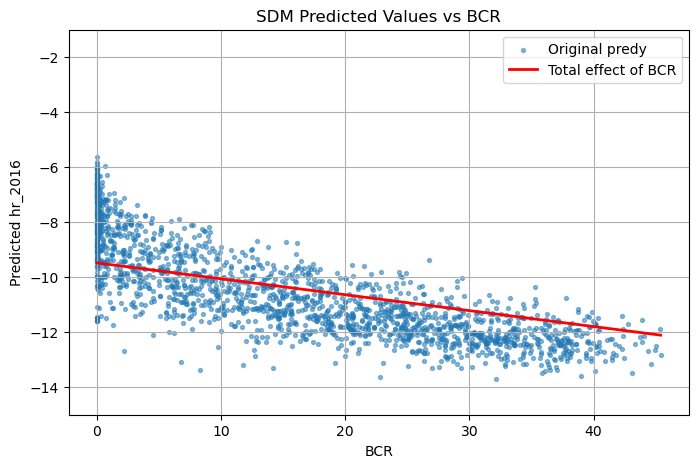

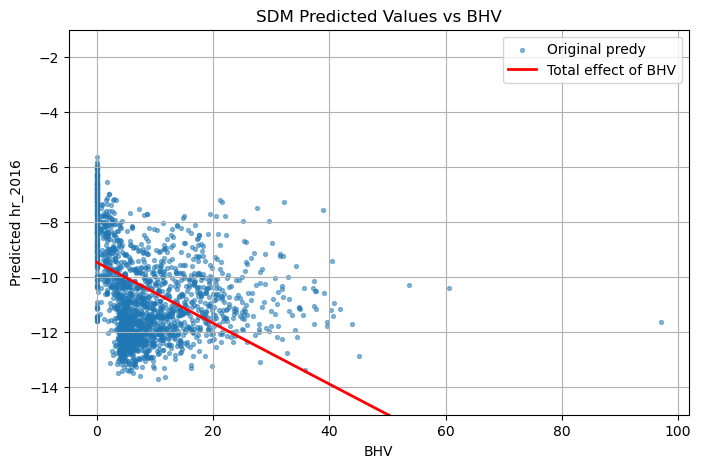

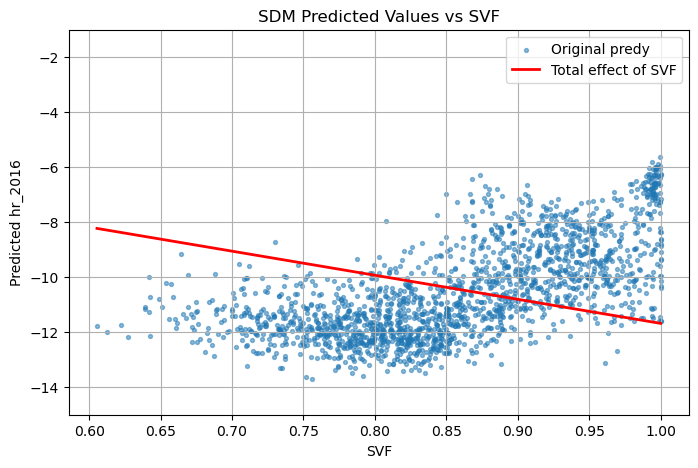

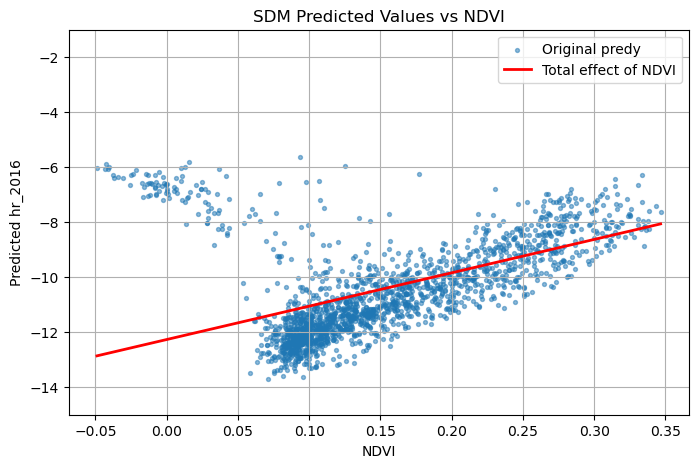

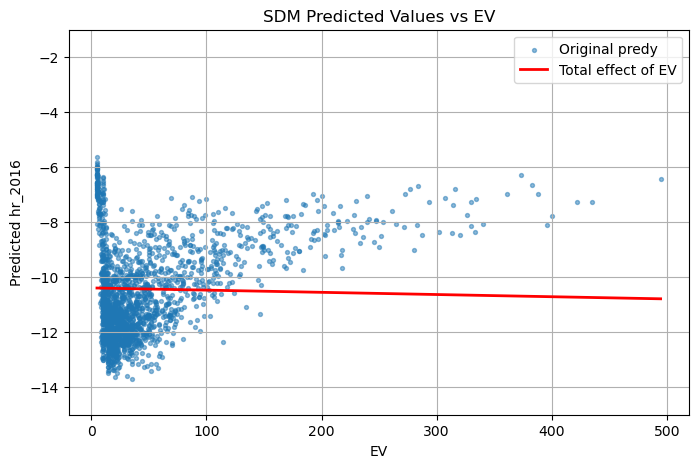

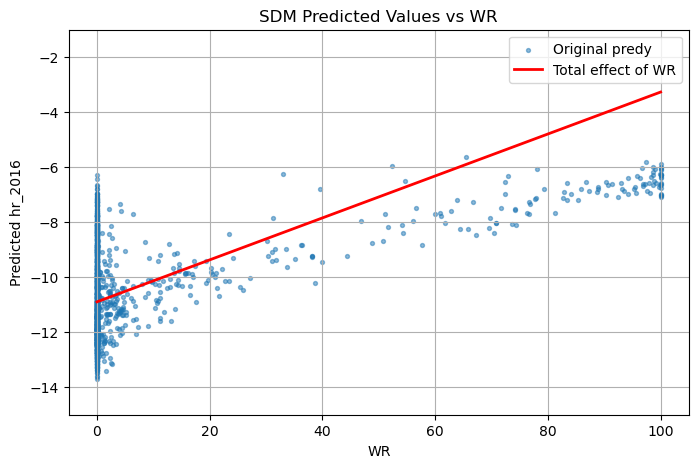

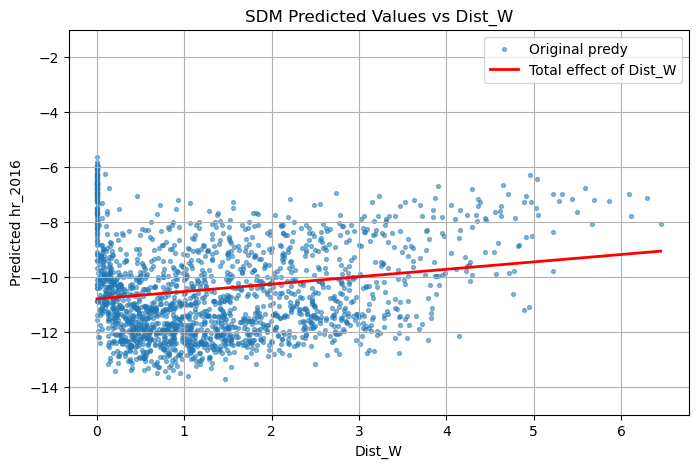

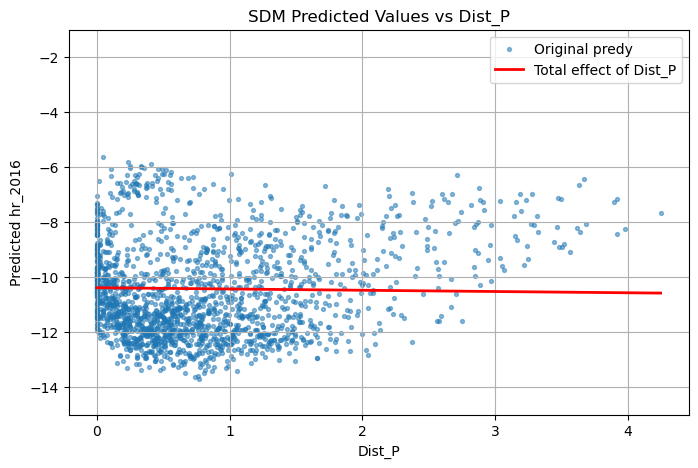

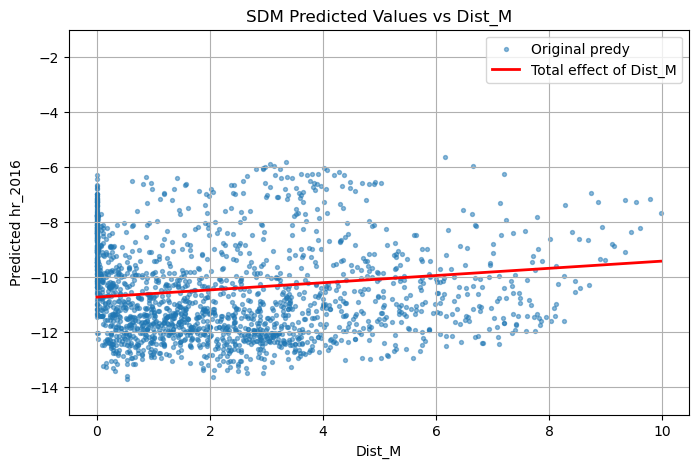

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from libpysal.weights import lag_spatial

for feature in explanatory_vars:
    other_features = [f for f in explanatory_vars if f != feature]

    # 用原数据均值固定其他变量
    X_matrix = data[explanatory_vars].copy().values  # 原始数据行数
    predy_list = []

    feature_min = data[feature].min()
    feature_max = data[feature].max()
    n_points = 100
    feature_range = np.linspace(feature_min, feature_max, n_points)

    for val in feature_range:
        X_matrix_temp = X_matrix.copy()
        X_matrix_temp[:, explanatory_vars.index(feature)] = val  # 修改 BCR
        # WX_clean
        WX_clean = lag_spatial(w, X_matrix_temp[:, :len(explanatory_vars_clean)])
        # I - rho*W
        I = np.eye(len(X_matrix_temp))
        W_dense = np.array(w.full()[0])
        y_temp = np.linalg.inv(I - rho * W_dense) @ (constant + X_matrix_temp @ beta + WX_clean @ theta)
        predy_list.append(y_temp.mean())  # 取平均作为单变量效果

    plt.figure(figsize=(8,5))

    plt.scatter(data[feature], model_sdm.predy.flatten(), s=8, alpha=0.5, label='Original predy')
    plt.plot(feature_range, predy_list, color='red', linewidth=2, label=f'Total effect of {feature}')

    plt.xlabel(feature)
    plt.ylabel(f"Predicted {target}")
    plt.title(f"SDM Predicted Values vs {feature}")
    plt.grid(True)
    plt.ylim(-15,-1)
    plt.legend()
    plt.show()

# 02  222222 读取excel 得到的

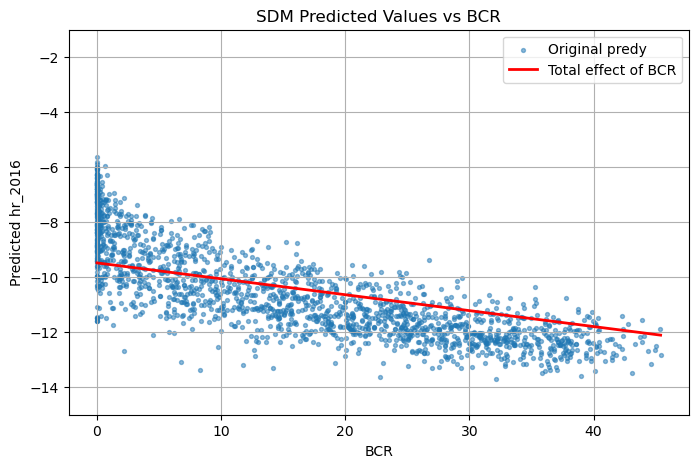

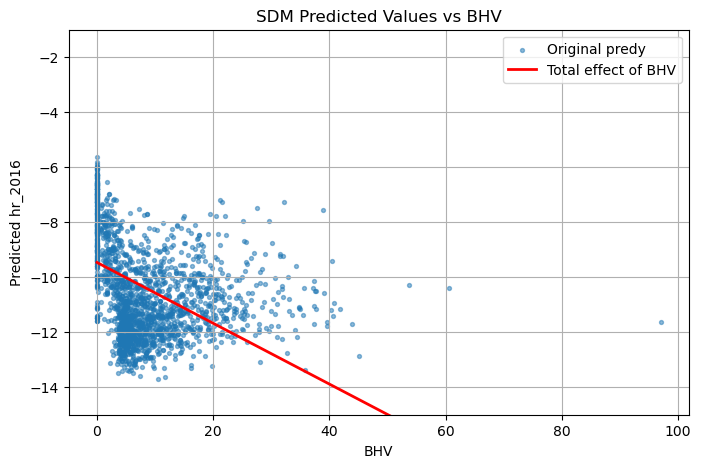

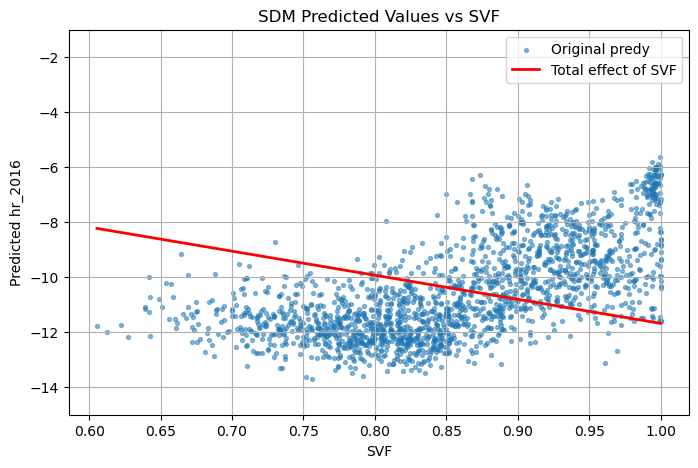

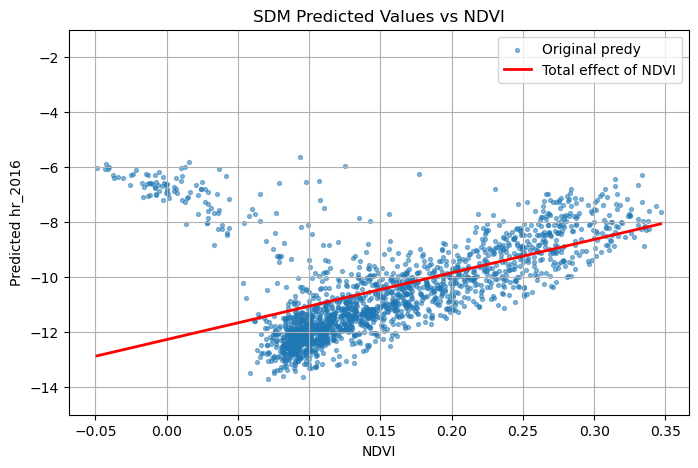

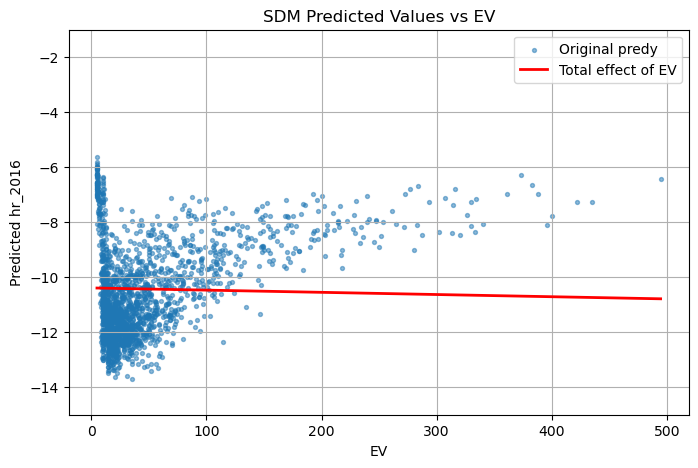

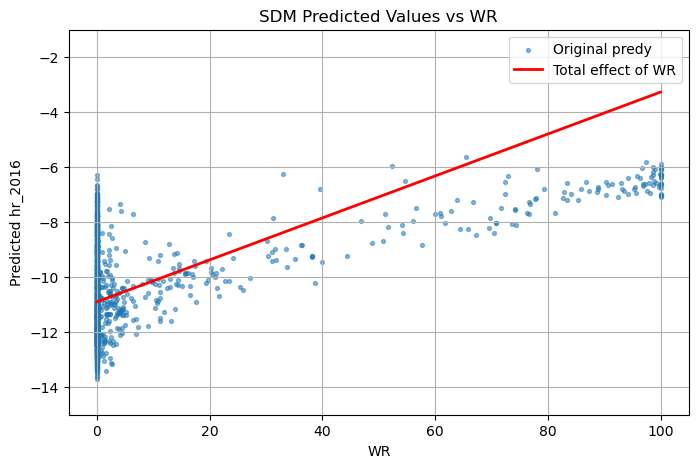

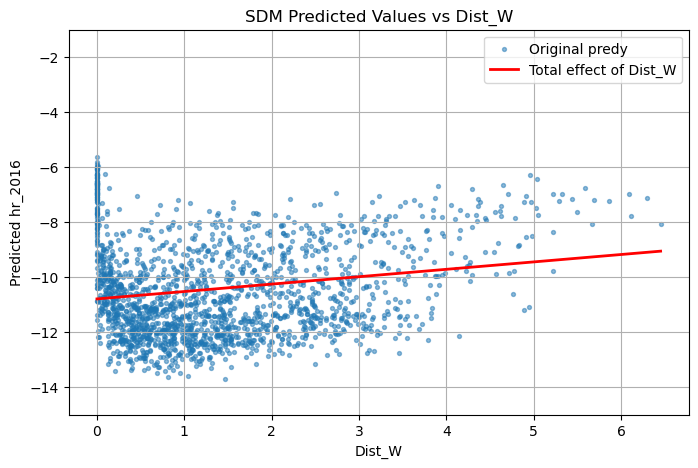

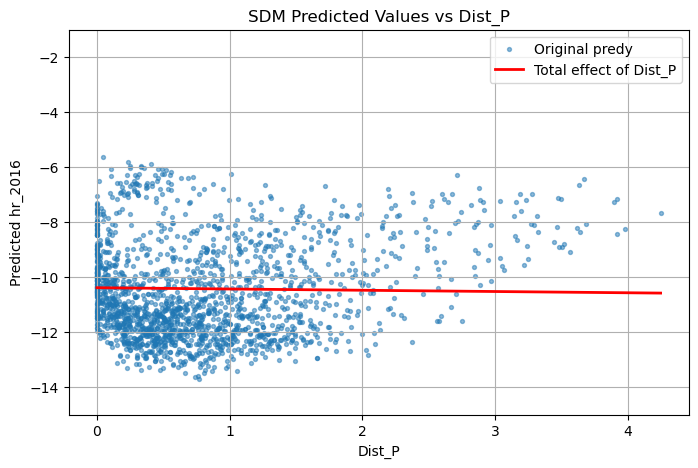

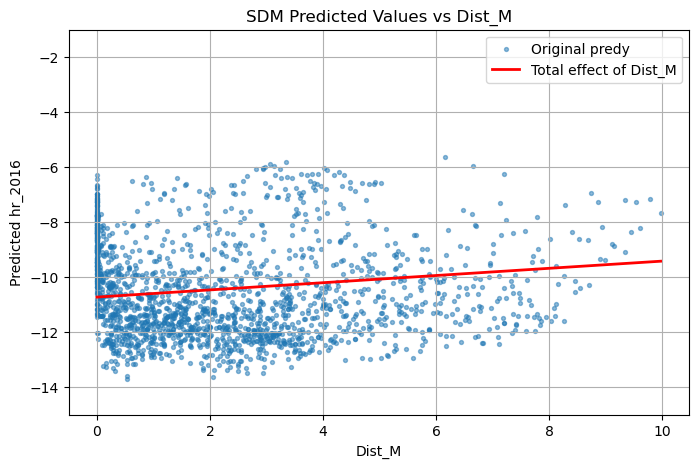

In [28]:
effects_file = r"E:\seoul\480_based\statistics\SDM_all_params_480m_NOW.xlsx"
df_effects = pd.read_excel(effects_file)

df_effects = df_effects[df_effects['Target'] == 'hr_2016'].reset_index(drop=True)
row = df_effects.loc[0]

explanatory_vars = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
explanatory_vars_clean = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR']
beta = np.array([row[v] for v in explanatory_vars])
theta = np.array([row[f"W_{v}"] for v in explanatory_vars_clean])
constant = np.ones(len(data)) * row['CONSTANT']

X_main = data[explanatory_vars].values
WX_clean = lag_spatial(w, data[explanatory_vars_clean].values)
W_dense = np.array(w.full()[0])
I = np.eye(len(data))

y_final = np.linalg.inv(I - rho * W_dense) @ (
    constant + X_main @ beta + WX_clean @ theta
)

import numpy as np
import matplotlib.pyplot as plt
from libpysal.weights import lag_spatial

for feature in explanatory_vars:
    other_features = [f for f in explanatory_vars if f != feature]

    # 用原数据均值固定其他变量
    X_matrix = data[explanatory_vars].copy().values  # 原始数据行数
    predy_list = []

    feature_min = data[feature].min()
    feature_max = data[feature].max()
    n_points = 100
    feature_range = np.linspace(feature_min, feature_max, n_points)

    for val in feature_range:
        X_matrix_temp = X_matrix.copy()
        X_matrix_temp[:, explanatory_vars.index(feature)] = val  # 修改 BCR
        # WX_clean
        WX_clean = lag_spatial(w, X_matrix_temp[:, :len(explanatory_vars_clean)])
        # I - rho*W
        I = np.eye(len(X_matrix_temp))
        W_dense = np.array(w.full()[0])
        y_temp = np.linalg.inv(I - rho * W_dense) @ (constant + X_matrix_temp @ beta + WX_clean @ theta)
        predy_list.append(y_temp.mean())  # 取平均作为单变量效果

    plt.figure(figsize=(8,5))

    plt.scatter(data[feature], model_sdm.predy.flatten(), s=8, alpha=0.5, label='Original predy')
    plt.plot(feature_range, predy_list, color='red', linewidth=2, label=f'Total effect of {feature}')

    plt.xlabel(feature)
    plt.ylabel(f"Predicted {target}")
    plt.title(f"SDM Predicted Values vs {feature}")
    plt.grid(True)
    plt.ylim(-15,-1)
    plt.legend()
    plt.show()

# 图像图像图像

In [18]:
df_impacts

,Variable,Direct,Indirect,Total
0,BCR,-0.0151,-0.0428,-0.0579
1,BHV,0.0103,-0.1209,-0.1106
2,SVF,-0.1790,-8.5746,-8.7536
3,NDVI,23.0632,-10.9302,12.1330
4,EV,0.0045,-0.0053,-0.0008
5,WR,0.0975,-0.0212,0.0763
6,Dist_W,0.0328,0.2363,0.2692
7,Dist_P,-0.0056,-0.0402,-0.0458
8,Dist_M,0.0160,0.1149,0.1309


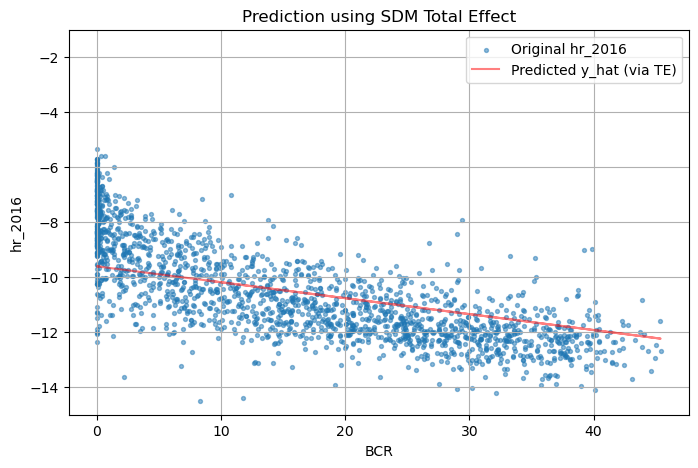

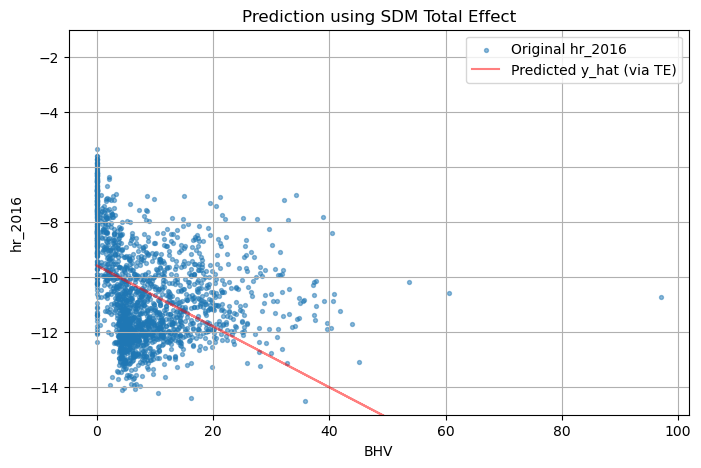

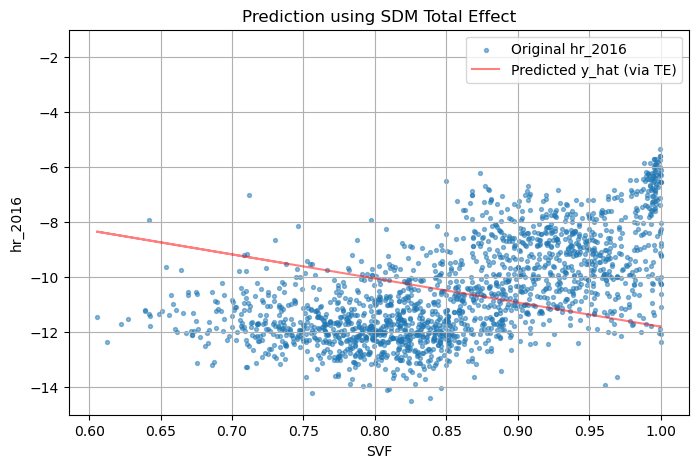

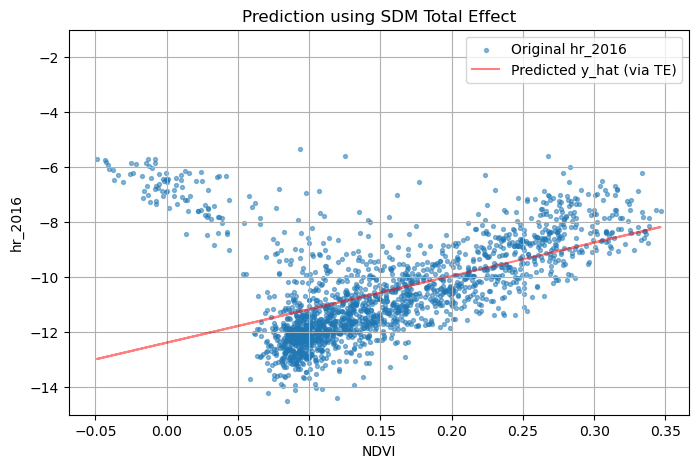

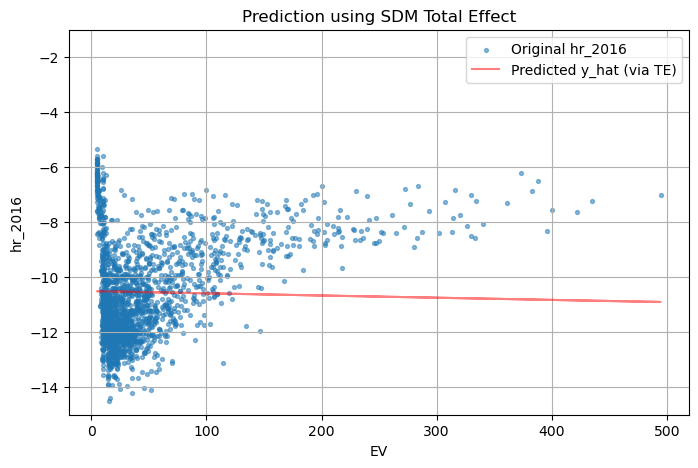

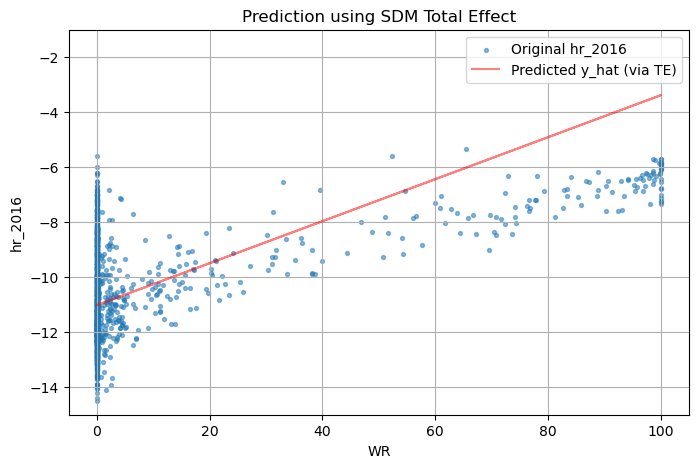

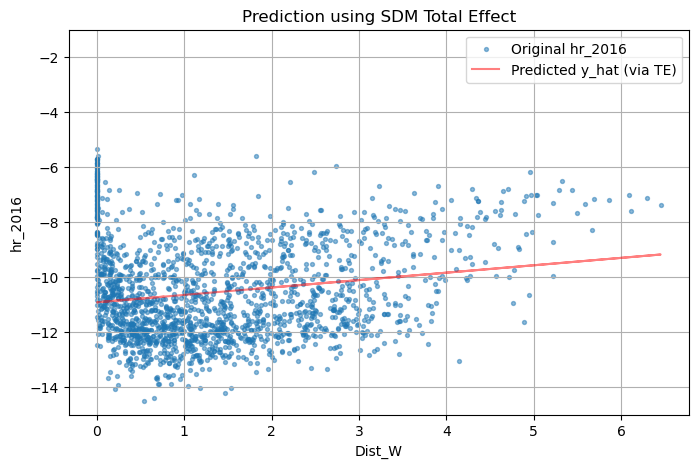

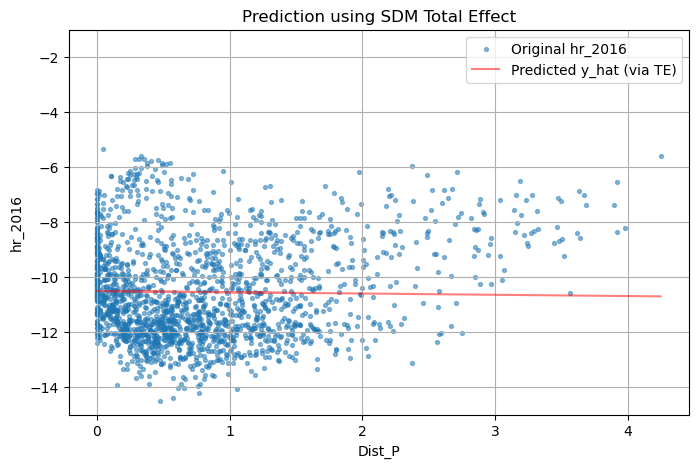

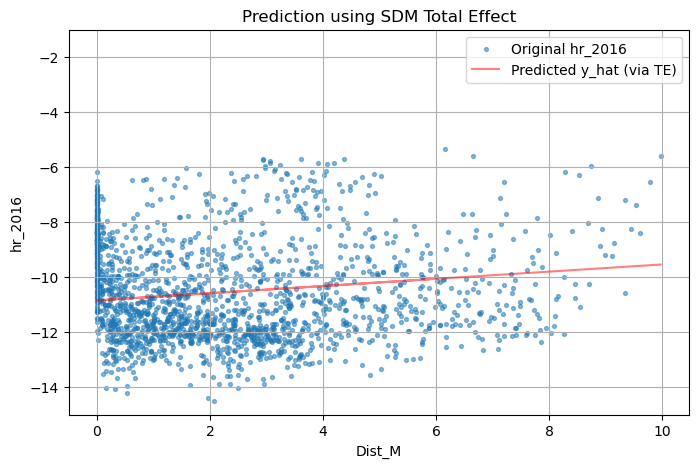

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_effects = df_impacts
for feature in explanatory_vars:
    TE_total = df_effects.loc[df_effects['Variable'] == feature, 'Total'].values[0]

    # -----------------------------
    # y_hat_i ≈ y_mean + TE_total * (BCR_i - BCR_mean)
    # -----------------------------
    y_base_mean = data['hr_2016'].mean()       # 或者使用模型原始 y_base.mean()
    bcr_mean = data[feature].mean()
    bcr_values = data[feature].values

    yhat = y_base_mean + TE_total * (bcr_values - bcr_mean)

    plt.figure(figsize=(8,5))
    plt.scatter(bcr_values, data['hr_2016'], s=8, alpha=0.5, label='Original hr_2016')
    plt.plot(bcr_values, yhat,color='red',  alpha=0.5, label='Predicted y_hat (via TE)')
    plt.xlabel(feature)
    plt.ylabel('hr_2016')
    plt.title('Prediction using SDM Total Effect')
    plt.legend()
    plt.ylim(-15,-1)
    plt.grid(True)
    plt.show()


# 480 + 完美的SDM斜率计算

In [22]:
import os
import geopandas as gpd
import pandas as pd
import numpy as np
import libpysal
from spreg import ML_Error, ML_Lag
from libpysal.weights import lag_spatial

# -----------------------------
# 设置路径
# -----------------------------
grid_folder = r"E:\seoul\480_based"
output_folder = os.path.join(grid_folder, 'statistics')
os.makedirs(output_folder, exist_ok=True)

# -----------------------------
# 准备变量
# -----------------------------
results_list = []
def show_formula(model, model_type='SDM'):
    # 处理 y 名称
    y_name = model.name_y if isinstance(model.name_y, str) else model.name_y[0]

    coefs = model.betas.flatten()
    vars_ = model.name_x

    terms = []
    for coef, var in zip(coefs, vars_):
        if var.lower() in ['const', 'constant']:  # 常数项
            terms.append(f"{coef:.4f}")
        else:
            terms.append(f"{coef:.4f}*{var}")

    formula = f"{y_name} = "

    # SDM rho 处理
    if model_type == 'SDM' and hasattr(model, 'rho'):
        rho_term = f"{model.rho:.4f}*W{y_name}"
        formula += " + ".join(terms[:1] + [rho_term] + terms[1:])  # 常数项 0 + Wy + X + WX
        return formula

    formula += " + ".join(terms)
    return formula


param_list = []
results_list = []
param_list = []

for year in [2016]: #2023, 

    target_vars = [f'nor_{year}', f'ext_{year}', f'hr_{year}']
    explanatory_vars = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
    explanatory_vars_clean = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR']

    for filename in os.listdir(grid_folder):
        if filename.endswith(f'city{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'):
            path = os.path.join(grid_folder, filename)
            gdf = gpd.read_file(path)
            gdf = gdf.replace([np.inf, -np.inf], np.nan)

            for target in target_vars:
                if target not in gdf.columns:
                    continue

                # 删除 NA
                data = gdf[explanatory_vars + [target]].dropna()
                data_gdf = gdf.loc[data.index]

                # 权重矩阵
                threshold = 1000
                w = DistanceBand.from_dataframe(data_gdf, threshold=threshold, binary=False)
                w.transform = 'r'

                # 孤岛
                row_sums = w.full()[0].sum(axis=1)
                islands = np.where(row_sums == 0)[0]
                data_gdf = data_gdf.drop(data_gdf.index[islands]).reset_index(drop=True)
                data = data_gdf[explanatory_vars + [target]]

                # 再生成权重
                w = DistanceBand.from_dataframe(data_gdf, threshold=1000, binary=False)
                w.transform = 'r'

                # y/X
                yi = data[target].values.reshape(-1, 1)
                X_main = data[explanatory_vars].values

                # SDM slx 变量
                slx_vars_bool = [v in explanatory_vars_clean for v in explanatory_vars]

                # --- 模型 ---
                model_sdm = ML_Lag(
                    yi, X_main, w=w,
                    slx_lags=1, slx_vars=slx_vars_bool,
                    name_y=target, name_x=explanatory_vars,
                    name_w=f"W{threshold}", name_ds=f"yr{year}",
                    spat_diag=True, spat_impacts=['full']
                )

                # --- 指标 ---
                loglik = model_sdm.logll
                aic = model_sdm.aic

                n = len(data)
                k = len(explanatory_vars)
                n_params = k + sum(slx_vars_bool) + 2  # β + WXβ + ρ + σ²
                bic = -2 * loglik + n_params * np.log(n)

                results_list.append({
                    "Year": year,
                    "Grid": filename.split("_")[4],
                    "Target": target,
                    "Model": "SDM",
                    "AIC": round(aic, 2),
                    "BIC": round(bic, 2),
                    "LogLik": round(loglik, 2),
                    "N": n
                })

                # --- 提取系数 ---
                formula_sdm = show_formula(model_sdm, model_type='SDM')
                coef_sdm = dict(zip(model_sdm.name_x, model_sdm.betas.flatten()))

                param_list.append({
                    "Year": year,
                    "Grid": filename.split("_")[4],
                    "Target": target,
                    "Model": "SDM",
                    "Formula": formula_sdm,
                    **coef_sdm
                })


# -----------------------------
# 输出
# -----------------------------
results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values(["Year", "Target", "Model"])

output_path = os.path.join(output_folder, "SDM_clean_AIC_BIC_480m_NOW.xlsx")
results_df.to_excel(output_path, index=False)

all_params_df = pd.DataFrame(param_list)
param_output = os.path.join(output_folder, "SDM_all_params_480m_NOW.xlsx")
all_params_df.to_excel(param_output, index=False)

print("保存完成")

c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(
c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There

('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(
c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There

('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(
c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There

('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')
保存完成


In [ ]:

                # feature_list = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
                # output_dir = r'E:\seoul\480_based\Machine Learning\figures\predict_predy'
                # os.makedirs(output_dir, exist_ok=True)

                # predy = models['SDM'].predy.flatten()      # predy 不用放到 loop 里重复算
                # mean_predy = predy.mean()                  # 该 target 的唯一 mean
                # csv_path = os.path.join(output_dir, "predy_feature_slopes.csv")
                # # 创建这一行数据
                # row = {
                #     "Year": year,
                #     "Target": target,
                #     "Mean_Predy": mean_predy,
                #     "Grid": filename.split("_")[4]   # 如果你想记录 grid 大小
                # }
                # slope_rows=[]
                # for feature in feature_list:
                #     plt.rcParams["font.family"] = "Times New Roman"
                #     plt.figure(figsize=(8, 5))

                #     # # 用 data
                #     plt.scatter(data[feature], predy, s=8, alpha=0.6)

                #     # --- ⭐ 计算斜率线（线性回归） ---
                #     coef = np.polyfit(data[feature], predy, 1)   
                #     slope = coef[0]
                #     intercept = coef[1]

                #     # 画回归线
                #     poly = np.poly1d(coef)
                #     x_line = np.linspace(data[feature].min(), data[feature].max(), 200)
                #     plt.plot(x_line, poly(x_line), linestyle='-', linewidth=1.2)
                #     # --- ⭐ 保存斜率公式 ---
                #     slope_rows.append({
                #         "Year": year,
                #         "Grid": filename.split("_")[4],
                #         "Target": target,
                #         "Feature": feature,
                #         "Mean": mean_predy,
                #         "Slope": slope,
                #         "Intercept": intercept,
                #         "Formula": f"predy = {slope:.4f} * {feature} + {intercept:.4f}"
                #     })

                #     plt.xlabel(feature, fontsize=16)
                #     plt.ylabel(f"Predicted {target} (SDM predy)")
                #     plt.title(f"SDM Predicted Values vs {feature}")
                #     plt.xticks(fontsize=12)
                #     plt.yticks(fontsize=12)
                #     plt.grid(False)
                #     plt.margins(x=0)

                #     save_name = f'{target}_{feature}_predy_480m.png'
                #     plt.savefig(os.path.join(output_dir, save_name), dpi=300)
                #     plt.close()

                #     # ----------------------------
                #     # ⭐ 保存 slope_rows → CSV（最小改动）
                #     # ----------------------------
                #     slope_df = pd.DataFrame(slope_rows)

                #     # 如果文件不存在 → 写入并写表头
                #     if not os.path.exists(output_folder):
                #         slope_df.to_csv(output_folder, index=False)
                #     else:
                #         # 文件存在 → 追加写入，不写表头
                #         slope_df.to_csv(output_folder, index=False, mode='a', header=False)

                #     print("斜率公式已保存到 predy_feature_slopes.csv")

# SDM 比较

In [3]:
y_pred = models['SDM'].predy
y_pred

array([[ -7.69446072],
       [ -7.2436461 ],
       [ -8.2679296 ],
       ...,
       [ -9.67375792],
       [-10.84455672],
       [ -9.45110436]])

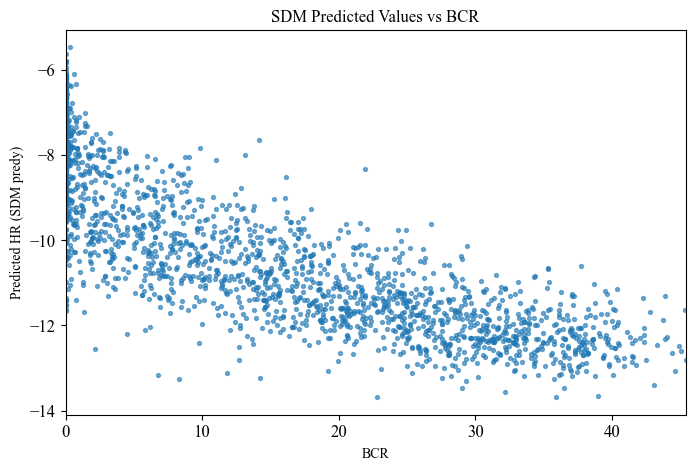

In [75]:
feature_list = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
output_dir = r'E:\seoul\480_based\Machine Learning\figures\real predict'
os.makedirs(output_dir,exist_ok=True)
for feature in feature_list:
    plt.rcParams["font.family"] = "Times New Roman"
    plt.figure(figsize=(8, 5))
    plt.scatter(gdf_clean['BCR'], models['SDM'].predy, s=8, alpha=0.6)
    plt.xlabel(feature, fontsize=16)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.ylabel("Predicted HR (SDM predy)")
    plt.title("SDM Predicted Values vs BCR")
    plt.margins(x=0)  # 去掉x方向留白
    plt.grid(False)
    plt.show()
    plt.savefig(os.path.join(output_dir, f'{feature}_hr_{year}_comparison_120m.png'), dpi=300)
    plt.close()

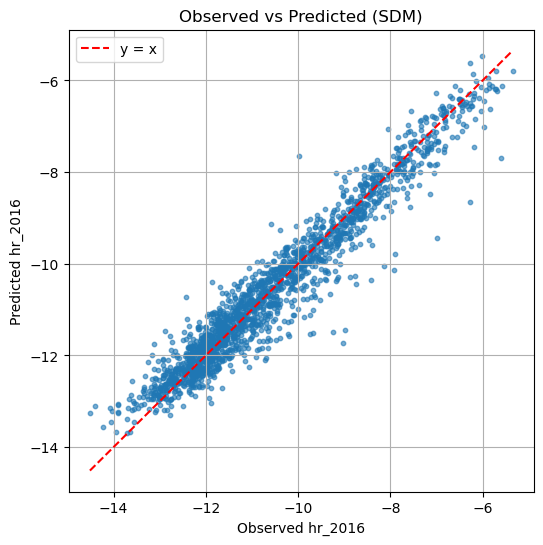

In [14]:
import matplotlib.pyplot as plt

y_true = gdf['hr_2016'].values  # 或你要对比的列
y_pred = models['SDM'].predy.flatten()  # 转成 1D

plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, s=10, alpha=0.6)
plt.plot([y_true.min(), y_true.max()],
         [y_true.min(), y_true.max()],
         'r--', label='y = x')
plt.xlabel('Observed hr_2016')
plt.ylabel('Predicted hr_2016')
plt.title('Observed vs Predicted (SDM)')
plt.legend()
plt.grid(True)
plt.show()


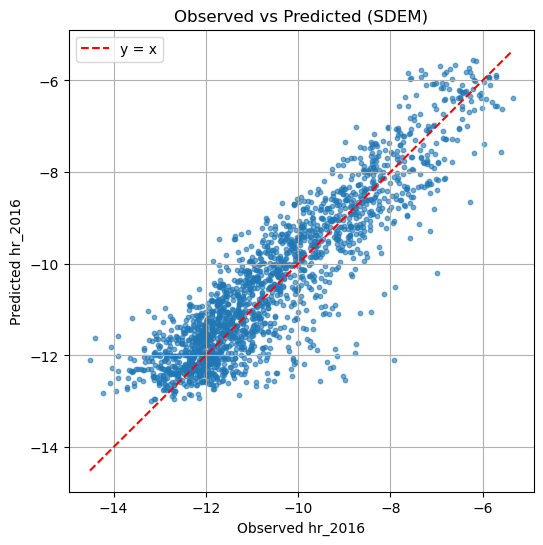

In [15]:
import matplotlib.pyplot as plt

y_true = gdf['hr_2016'].values  # 或你要对比的列
y_pred = models['SDEM'].predy.flatten()  # 转成 1D

plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, s=10, alpha=0.6)
plt.plot([y_true.min(), y_true.max()],
         [y_true.min(), y_true.max()],
         'r--', label='y = x')
plt.xlabel('Observed hr_2016')
plt.ylabel('Predicted hr_2016')
plt.title('Observed vs Predicted (SDEM)')
plt.legend()
plt.grid(True)
plt.show()


In [59]:
y_pred = models['SDM'].predy  # shape: (n,)
y_base_mean = y_pred.mean()   # 所有观测点的平均预测值
y_base_mean

-10.537053757494542

predy length: 1861
gdf length: 1861
平均误差: 0.001795
RMSE: 0.002787
相关系数: 0.999999


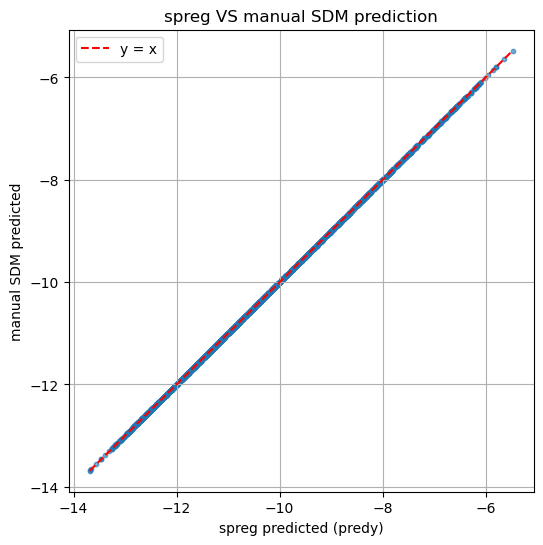

In [9]:
import geopandas as gpd
import numpy as np
from libpysal.weights import DistanceBand, lag_spatial
import matplotlib.pyplot as plt

# -----------------------------
# 1️⃣ 读取 shapefile
# -----------------------------
file = r'E:\seoul\480_based\city2016_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'
gdf_clean = gpd.read_file(file).replace([np.inf, -np.inf], np.nan)

vars_base = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']

# -----------------------------
# 2️⃣ 空间权重矩阵 W
# -----------------------------
data_gdf = gdf.loc[data.index]
w.transform = 'r'

# -----------------------------
# 3️⃣ 空间滞后变量
# -----------------------------
for var in vars_base + ['hr_2016']:
    gdf[f'W_{var}'] = lag_spatial(w, gdf[var])

# -----------------------------
# 4️⃣ 你手动计算的 SDM 预测
# -----------------------------
gdf['pred_manual'] = (
    -9.1532
    + -0.0197 * gdf['BCR']
    + 0.0003 * gdf['BHV']
    + -1.9617 * gdf['SVF']
    + 17.0564 * gdf['NDVI']
    + 0.0032 * gdf['EV']
    + 0.0734 * gdf['WR']
    + 0.0407 * gdf['Dist_W']
    + -0.0050 * gdf['Dist_P']
    + 0.0409 * gdf['Dist_M']
    + 0.0547 * gdf['W_BCR']
    + 0.0456 * gdf['W_BHV']
    + 8.5564 * gdf['W_SVF']
    + -13.9486 * gdf['W_NDVI']
    + 0.0001 * gdf['W_EV']
    + -0.0581 * gdf['W_WR']
    + 0.8417 * gdf['W_hr_2016']
)

# -----------------------------
# 5️⃣ spreg 模型的预测值 (predy)
# -----------------------------
pred_spreg = models['SDM'].predy.flatten()

# 检查长度一致（重要）
print("predy length:", len(pred_spreg))
print("gdf length:", len(gdf))

# -----------------------------
# 6️⃣ 误差对比
# -----------------------------
gdf['error'] = pred_spreg - gdf['pred_manual']
rmse = np.sqrt(np.mean(gdf['error'] ** 2))
corr = np.corrcoef(pred_spreg, gdf['pred_manual'])[0, 1]

print(f"平均误差: {gdf['error'].mean():.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"相关系数: {corr:.6f}")

# -----------------------------
# 7️⃣ 散点图：spreg vs manual
# -----------------------------
plt.figure(figsize=(6,6))
plt.scatter(pred_spreg, gdf['pred_manual'], s=10, alpha=0.6)
plt.plot([pred_spreg.min(), pred_spreg.max()],
         [pred_spreg.min(), pred_spreg.max()],
         'r--', label='y = x')
plt.xlabel('spreg predicted (predy)')
plt.ylabel('manual SDM predicted')
plt.title('spreg VS manual SDM prediction')
plt.legend()
plt.grid(True)
plt.show()


# 111111111111111111111

c:\Users\JUJUBE\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(


('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(


y_final min/mean/max: -14.191522928508828 -10.496593819893079 -5.277319996077357
原始 hr_2016 min/mean/max: -14.511600494384766 -10.543430219634844 -5.352798461914062


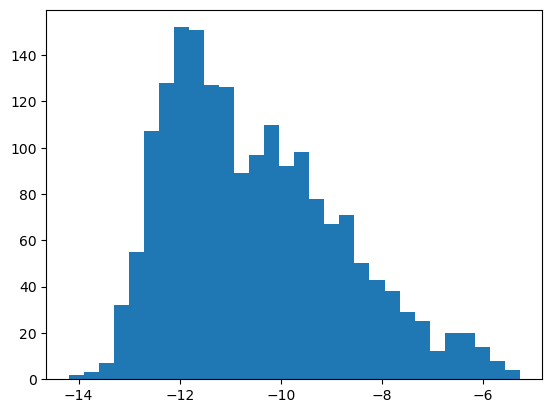

差值 min/mean/max: -4.954469057354043 0.046836399741766066 2.5728927915034365
有差异的行数: 1855
行 0: 原始=-5.594813823699951, 计算=-7.951393242892088, 差=-2.356579419192137
行 1: 原始=-6.555527210235596, 计算=-7.6863288206733404, 差=-1.1308016104377447
行 2: 原始=-8.384675025939941, 计算=-8.702816855038982, 差=-0.31814182909904076
行 3: 原始=-8.254777908325195, 计算=-8.770062612656677, 差=-0.5152847043314814
行 4: 原始=-7.365075588226318, 计算=-7.863003863163265, 差=-0.4979282749369469
行 5: 原始=-10.59528636932373, 计算=-9.639569676663864, 差=0.9557166926598661
行 6: 原始=-8.754494667053223, 计算=-9.074624991842626, 差=-0.3201303247894032
行 7: 原始=-9.18896198272705, 计算=-9.613358499291625, 差=-0.424396516564574
行 8: 原始=-7.116199016571045, 计算=-7.868430936925421, 差=-0.7522319203543759
行 9: 原始=-5.974131107330322, 计算=-7.705626633414147, 差=-1.7314955260838252


In [ ]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
from libpysal.weights import DistanceBand, lag_spatial
import matplotlib.pyplot as plt

file = r'E:\seoul\480_based\city2016_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'
gdf_clean = gpd.read_file(file).replace([np.inf, -np.inf], np.nan)

explanatory_vars = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
explanatory_vars_clean = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR']
year = 2016
target = f'hr_{year}'

best_params_file_sdm = rf'E:\seoul\480_based\statistics\SDM_SDEM_all_params.xlsx'
best_df_sdm = pd.read_excel(best_params_file_sdm)
best_df_sdm = best_df_sdm[best_df_sdm['Model']=='SDM']

row_sdm = best_df_sdm[best_df_sdm['Target']==target].iloc[0]

# 参数
constant = float(row_sdm['CONSTANT'])
rho = float(row_sdm[[c for c in row_sdm.index if c.lower()==f'w_{target.lower()}'][0]])
beta = np.array([row_sdm[var] for var in explanatory_vars], dtype=float)
theta = np.array([row_sdm[f"W_{var}"] for var in explanatory_vars_clean], dtype=float)

# 数据
data = gdf_clean[explanatory_vars + [target]].dropna()
data_gdf = gdf_clean.loc[data.index]
# 构造 W 
w = DistanceBand.from_dataframe(data_gdf, threshold=1000, binary=False) 
w.transform = 'r'

# 找孤岛
row_sums = w.full()[0].sum(axis=1)
islands = np.where(row_sums == 0)[0]

# 删除孤岛
data_gdf = data_gdf.drop(data_gdf.index[islands]).reset_index(drop=True)
data = data_gdf[explanatory_vars + [target]]

# 再生成 W
w = DistanceBand.from_dataframe(data_gdf, threshold=1000, binary=False)
w.transform = 'r'
W = np.array(w.full()[0])  # 稠密矩阵

# 保证 data_gdf 行顺序与 W 对齐
# data_gdf = data_gdf.loc[ids]
data = data_gdf[explanatory_vars + [target]]

X_main = data[explanatory_vars].values
WX_clean = lag_spatial(w, data[explanatory_vars_clean].values)

# SDM 计算
I = np.eye(len(X_main))
A_inv = np.linalg.inv(I - rho * W)

y_result = constant + X_main @ beta + WX_clean @ theta
X_all = np.hstack([np.ones((len(data), 1)), X_main, WX_clean])
beta_all = np.array([row_sdm[var] for var in ['CONSTANT'] + explanatory_vars + [f"W_{v}" for v in explanatory_vars_clean]], dtype=float)
y_final = np.linalg.inv(I - rho * W) @ (X_all @ beta_all)

# 检查与原值差异
print("y_final min/mean/max:", y_final.min(), y_final.mean(), y_final.max())
print("原始 hr_2016 min/mean/max:", data[target].min(), data[target].mean(), data[target].max())

# 可视化
plt.hist(y_final, bins=30)
plt.show()
# 原始目标
y_orig = data['hr_2016'].values

# 反算得到的
y_calc = y_final

# 逐行差值
diff = y_calc - y_orig

# 输出最大差、最小差、平均差
print("差值 min/mean/max:", diff.min(), diff.mean(), diff.max())

# 查看哪些行有差异
mismatch_idx = np.where(np.abs(diff) > 1e-8)[0]
print("有差异的行数:", len(mismatch_idx))

# 如果想看前几行的对比
for i in mismatch_idx[:10]:
    print(f"行 {i}: 原始={y_orig[i]}, 计算={y_calc[i]}, 差={diff[i]}")


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(


差值 min/mean/max: -2.588925805337867 -5.672539407350016e-13 1.5142801376416006
原始 hr_2016 min/mean/max: -14.511600494384766 -10.543430219634844 -5.352798461914062


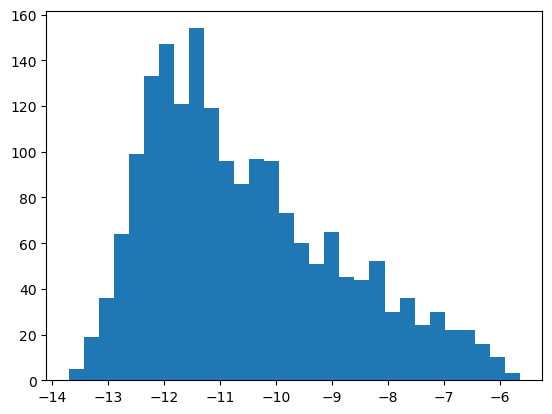

差值 min/mean/max: -2.588925805337867 -5.672539407350016e-13 1.5142801376416006
有差异的行数: 1855
行 0: 原始=-5.594813823699951, 计算=-7.6610944431291355, 差=-2.0662806194291843
行 1: 原始=-6.555527210235596, 计算=-7.1726462955971035, 差=-0.6171190853615078
行 2: 原始=-8.384675025939941, 计算=-8.205779415259629, 差=0.17889561068031234
行 3: 原始=-8.254777908325195, 计算=-8.370316975431587, 差=-0.11553906710639161
行 4: 原始=-7.365075588226318, 计算=-7.261829338120841, 差=0.10324625010547717
行 5: 原始=-10.59528636932373, 计算=-9.08100623168213, 差=1.5142801376416006
行 6: 原始=-8.754494667053223, 计算=-8.856248287329569, 差=-0.10175362027634627
行 7: 原始=-9.18896198272705, 计算=-9.378961456787538, 差=-0.18999947406048712
行 8: 原始=-7.116199016571045, 计算=-7.265438572293448, 差=-0.14923955572240288
行 9: 原始=-5.974131107330322, 计算=-6.932041435973372, 差=-0.9579103286430497


In [ ]:
import os
import geopandas as gpd
import pandas as pd
import numpy as np
import libpysal
from spreg import ML_Error, ML_Lag
from libpysal.weights import lag_spatial
import os
import numpy as np
import pandas as pd
import geopandas as gpd
from libpysal.weights import DistanceBand, lag_spatial
import matplotlib.pyplot as plt

file = r'E:\seoul\480_based\city2016_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'
gdf_clean = gpd.read_file(file).replace([np.inf, -np.inf], np.nan)

explanatory_vars = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
explanatory_vars_clean = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR']
year = 2016
target = f'hr_{year}'

best_params_file_sdm = rf'E:\seoul\480_based\statistics\SDM_SDEM_all_params.xlsx'
best_df_sdm = pd.read_excel(best_params_file_sdm)
best_df_sdm = best_df_sdm[best_df_sdm['Model']=='SDM']

row_sdm = best_df_sdm[best_df_sdm['Target']==target].iloc[0]

# 参数
constant = float(row_sdm['CONSTANT'])
rho = float(row_sdm[[c for c in row_sdm.index if c.lower()==f'w_{target.lower()}'][0]])
beta = np.array([row_sdm[var] for var in explanatory_vars], dtype=float)
theta = np.array([row_sdm[f"W_{var}"] for var in explanatory_vars_clean], dtype=float)

# 数据
data = gdf_clean[explanatory_vars + [target]].dropna()
data_gdf = gdf_clean.loc[data.index]
# 构造 W 
w = DistanceBand.from_dataframe(data_gdf, threshold=1000, binary=False) 
w.transform = 'r'

# 找孤岛
row_sums = w.full()[0].sum(axis=1)
islands = np.where(row_sums == 0)[0]

# 删除孤岛
data_gdf = data_gdf.drop(data_gdf.index[islands]).reset_index(drop=True)
data = data_gdf[explanatory_vars + [target]]

# 再生成 W
w = DistanceBand.from_dataframe(data_gdf, threshold=1000, binary=False)
w.transform = 'r'
W = np.array(w.full()[0])  # 稠密矩阵

# 保证 data_gdf 行顺序与 W 对齐
# data_gdf = data_gdf.loc[ids]
data = data_gdf[explanatory_vars + [target]]

X_main = data[explanatory_vars].values
WX_clean = lag_spatial(w, data[explanatory_vars_clean].values)

# SDM 计算
I = np.eye(len(X_main))
A_inv = np.linalg.inv(I - rho * W)

y_result = constant + X_main @ beta + WX_clean @ theta
X_all = np.hstack([np.ones((len(data), 1)), X_main, WX_clean])
beta_all = np.array([row_sdm[var] for var in ['CONSTANT'] + explanatory_vars + [f"W_{v}" for v in explanatory_vars_clean]], dtype=float)
y_final = np.linalg.inv(I - rho * W) @ (X_all @ beta_all)

models = {}
# -----------------------------
# y 与 X
# -----------------------------
yi = data[target].values.reshape(-1, 1)
X_main = data[explanatory_vars].values
WX_clean = lag_spatial(w, data[explanatory_vars_clean].values)
X_all = np.hstack([np.ones((len(data), 1)), X_main, WX_clean])
name_x = ['const'] + explanatory_vars + [f"W_{v}" for v in explanatory_vars_clean]
# print(len(name_x), X_all.shape[1])
threshold = 1000
w = libpysal.weights.DistanceBand.from_dataframe(data_gdf, threshold=threshold, binary=False)
w.transform = 'r'  # 行标准化
w_name = 'W1000'
ds_name = f'yr{year}'

n, k = X_main.shape  # 原始自变量数量
# SDM
models['SDM'] = ML_Lag(
    yi, X_all, w=w,
    name_y=target, name_x=name_x,
    name_w=w_name, name_ds=ds_name,
    spat_diag=True, spat_impacts=['full']
)
# 使用训练模型 predy
predy = models['SDM'].predy.flatten()

# 仅检查差异
diff = predy - data[target].values
print("差值 min/mean/max:", diff.min(), diff.mean(), diff.max())
print("原始 hr_2016 min/mean/max:", data[target].min(), data[target].mean(), data[target].max())

# 原始目标
y_orig = data['hr_2016'].values

# 反算得到的
y_calc = predy

# 逐行差值
diff = y_calc - y_orig

# 输出最大差、最小差、平均差
print("差值 min/mean/max:", diff.min(), diff.mean(), diff.max())

# 查看哪些行有差异
mismatch_idx = np.where(np.abs(diff) > 1e-8)[0]
print("有差异的行数:", len(mismatch_idx))

# 如果想看前几行的对比
for i in mismatch_idx[:10]:
    print(f"行 {i}: 原始={y_orig[i]}, 计算={y_calc[i]}, 差={diff[i]}")

差值 min/mean/max: -2.365217737270399 -0.04683639974233333 3.9211809419772585
公式计算 hr_2016 min/mean/max: -14.191522928508828 -10.496593819893079 -5.277319996077357


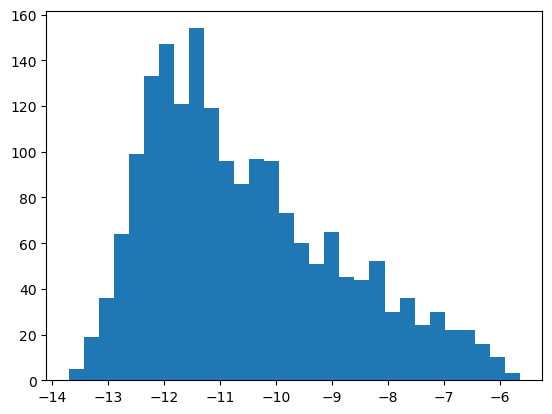

差值 min/mean/max: -2.365217737270399 -0.04683639974233333 3.9211809419772585
有差异的行数: 1855
row 0: formula =-7.951393242892088, predy =-7.6610944431291355, difference =0.2902987997629527
row 1: formula =-7.6863288206733404, predy =-7.1726462955971035, difference =0.5136825250762369
row 2: formula =-8.702816855038982, predy =-8.205779415259629, difference =0.4970374397793531
row 3: formula =-8.770062612656677, predy =-8.370316975431587, difference =0.3997456372250898
row 4: formula =-7.863003863163265, predy =-7.261829338120841, difference =0.6011745250424241
row 5: formula =-9.639569676663864, predy =-9.08100623168213, difference =0.5585634449817345
row 6: formula =-9.074624991842626, predy =-8.856248287329569, difference =0.2183767045130569
row 7: formula =-9.613358499291625, predy =-9.378961456787538, difference =0.23439704250408688
row 8: formula =-7.868430936925421, predy =-7.265438572293448, difference =0.602992364631973
row 9: formula =-7.705626633414147, predy =-6.932041435973372, 

In [4]:

# 仅检查差异
diff = predy - y_final
print("差值 min/mean/max:", diff.min(), diff.mean(), diff.max())
print("公式计算 hr_2016 min/mean/max:", y_final.min(), y_final.mean(), y_final.max())

# 可视化
plt.hist(predy, bins=30)
plt.show()
# 原始目标

# 反算得到的
y_calc = predy

# 逐行差值
diff = y_calc - y_final

# 输出最大差、最小差、平均差
print("差值 min/mean/max:", diff.min(), diff.mean(), diff.max())

# 查看哪些行有差异
mismatch_idx = np.where(np.abs(diff) > 1e-8)[0]
print("有差异的行数:", len(mismatch_idx))

# 如果想看前几行的对比
for i in mismatch_idx[:10]:
    print(f"row {i}: formula ={y_final[i]}, predy ={y_calc[i]}, difference ={diff[i]}")

C:\Users\JUJUBE\AppData\Local\Temp\ipykernel_16240\3029034192.py:16: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from current font.
  plt.tight_layout()
C:\Users\JUJUBE\AppData\Local\Temp\ipykernel_16240\3029034192.py:16: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from current font.
  plt.tight_layout()
C:\Users\JUJUBE\AppData\Local\Temp\ipykernel_16240\3029034192.py:16: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from current font.
  plt.tight_layout()
C:\Users\JUJUBE\AppData\Local\Temp\ipykernel_16240\3029034192.py:16: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from current font.
  plt.tight_layout()
C:\Users\JUJUBE\AppData\Local\Temp\ipykernel_16240\3029034192.py:16: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from current font.
  plt.tight_layout()


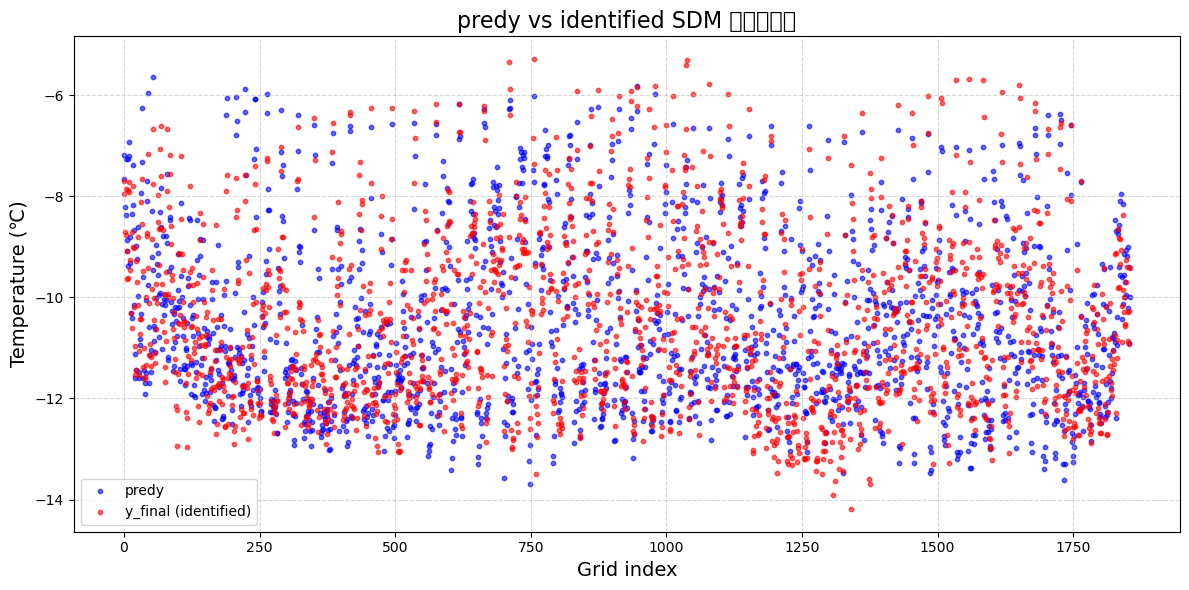

In [55]:
import matplotlib.pyplot as plt
import numpy as np

# x 轴为行号
x = np.arange(len(predy))

plt.figure(figsize=(12,6))
plt.scatter(x, predy, s=10, alpha=0.6, label='predy', color='blue')
plt.scatter(x, y_final, s=10, alpha=0.6, label='y_final (identified)', color='red')

plt.xlabel('Grid index', fontsize=14)
plt.ylabel('Temperature (℃)', fontsize=14)
plt.title('predy vs identified SDM 预测值对比', fontsize=16)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [4]:
beta

array([-1.97153261e-02,  3.37478822e-04, -1.96172544e+00,  1.70564059e+01,
        3.22471263e-03,  7.33976189e-02,  4.06837933e-02, -4.97740565e-03,
        4.08870306e-02])

In [5]:
theta

array([ 5.46752015e-02,  4.56330439e-02,  8.55637262e+00, -1.39485874e+01,
        1.13266323e-04, -5.80549868e-02])

In [6]:
rho

0.8417214637920494

In [7]:
A_inv

array([[1.21820519e+00, 4.69677157e-01, 3.23558156e-01, ...,
        3.90602507e-20, 3.42193517e-20, 2.66096943e-20],
       [3.21587486e-01, 1.27818246e+00, 3.78632667e-01, ...,
        3.63093979e-20, 3.18102952e-20, 2.47367006e-20],
       [2.21539951e-01, 3.78632667e-01, 1.25927688e+00, ...,
        3.47160889e-20, 3.04154395e-20, 2.36524166e-20],
       ...,
       [2.44843910e-20, 3.32409651e-20, 3.17823034e-20, ...,
        1.26751990e+00, 3.53858462e-01, 2.32018109e-01],
       [2.34308299e-20, 3.18114811e-20, 3.04165735e-20, ...,
        3.86537114e-01, 1.27305783e+00, 3.56547009e-01],
       [2.23479558e-20, 3.03417055e-20, 2.90117372e-20, ...,
        3.10860487e-01, 4.37319480e-01, 1.28495373e+00]])

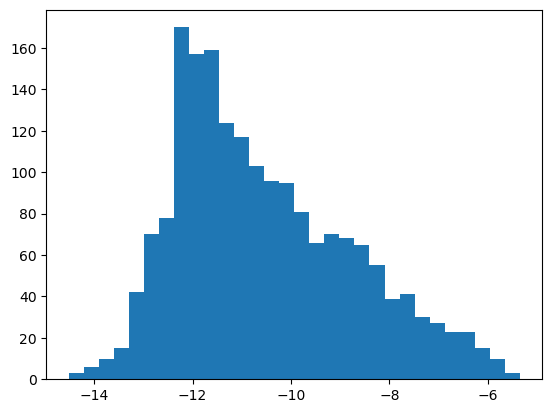

In [23]:
y_real = gdf_clean['hr_2016']
plt.hist(y_real, bins=30)
plt.show()

In [18]:
corr = np.corrcoef(y_real, y_final)[0,1]
print("相关系数：", corr)

相关系数： 0.8477523517304711


# SDEM 比较

In [11]:
import os
import geopandas as gpd
import pandas as pd
import numpy as np
import libpysal
from spreg import ML_Error, ML_Lag
from libpysal.weights import lag_spatial

# -----------------------------
# 设置路径
# -----------------------------
grid_folder = r"E:\seoul\480_based"
output_folder = os.path.join(grid_folder, 'statistics')
os.makedirs(output_folder, exist_ok=True)

# -----------------------------
# 准备变量
# -----------------------------
results_list = []
def show_formula(model, model_type='SDM'):
    # 处理 y 名称
    y_name = model.name_y if isinstance(model.name_y, str) else model.name_y[0]

    coefs = model.betas.flatten()
    vars_ = model.name_x

    terms = []
    for coef, var in zip(coefs, vars_):
        if var.lower() in ['const', 'constant']:  # 常数项
            terms.append(f"{coef:.4f}")
        else:
            terms.append(f"{coef:.4f}*{var}")

    formula = f"{y_name} = "

    # SDM rho 处理
    if model_type == 'SDM' and hasattr(model, 'rho'):
        rho_term = f"{model.rho:.4f}*W{y_name}"
        formula += " + ".join(terms[:1] + [rho_term] + terms[1:])  # 常数项 0 + Wy + X + WX
        return formula

    # SDEM lambda 处理
    if model_type == 'SDEM' and hasattr(model, 'lambda_'):
        terms.append(f"{model.lambda_:.4f}*error")

    formula += " + ".join(terms)
    return formula


param_list = []

for year in [2023, 2016]:
    target_vars = [f'nor_{year}', f'ext_{year}', f'hr_{year}']
    explanatory_vars = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
    explanatory_vars_clean = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR']

    for filename in os.listdir(grid_folder):
        if filename.endswith('.shp') and filename.startswith(f'city{year}_lst_ratio_grid_480m'):
            path = os.path.join(grid_folder, filename)
            gdf = gpd.read_file(path)
            gdf = gdf.replace([np.inf, -np.inf], np.nan)

            for target in target_vars:
                if target not in gdf.columns:
                    continue

                # 只保留完整数据
                data = gdf[explanatory_vars + [target]].dropna()
                if data.empty:
                    continue

                data_gdf = gdf.loc[data.index]
                print(f"CRS: {data_gdf.crs}, File: {filename}, Target: {target}")

                # -----------------------------
                # 空间权重矩阵
                # -----------------------------
                threshold = 1000
                w = libpysal.weights.DistanceBand.from_dataframe(data_gdf, threshold=threshold, binary=False)
                w.transform = 'r'  # 行标准化
                w_name = 'W1000'
                ds_name = f'yr{year}'

                # -----------------------------
                # y 与 X
                # -----------------------------
                yi = data[target].values.reshape(-1, 1)
                X_main = data[explanatory_vars].values
                WX_clean = lag_spatial(w, data[explanatory_vars_clean].values)
                X_all = np.hstack([np.ones((len(data), 1)), X_main, WX_clean])
                name_x = ['const'] + explanatory_vars + [f"W_{v}" for v in explanatory_vars_clean]
                # print(len(name_x), X_all.shape[1])
                
                n, k = X_main.shape  # 原始自变量数量

                # -----------------------------
                # 模型估计
                # -----------------------------
                models = {}

                # SDM
                models['SDM'] = ML_Lag(
                    yi, X_all, w=w,
                    name_y=target, name_x=name_x,
                    name_w=w_name, name_ds=ds_name,
                    spat_diag=True, spat_impacts=['full']
                )

                # SDEM
                models['SDEM'] = ML_Error(
                    yi, X_all, w=w,
                    name_y=target, name_x=name_x,
                    name_w=w_name, name_ds=ds_name,
                    spat_diag=True
                )

                # -----------------------------
                # 提取 AIC/BIC/logLik
                # -----------------------------
                for model_name, model in models.items():
                    loglik = model.logll
                    aic = model.aic

                    # 参数数量估算
                    if model_name in ['SDM', 'SDEM']:
                        n_params = 2 * k + 3  # k原始 + k滞后 + ρ/λ + 常数 + σ²
                    else:
                        n_params = k + 2

                    bic = -2 * loglik + n_params * np.log(n)

                    results_list.append({
                        "Year": year,
                        "Grid": filename.split("_")[4],
                        "Target": target,
                        "Model": model_name,
                        "AIC": round(aic, 2),
                        "BIC": round(bic, 2),
                        "LogLik": round(loglik, 2),
                        "N": n
                    })

                    formula_sdm = show_formula(models['SDM'], model_type='SDM')
                    print(formula_sdm)
                    formula_sdem = show_formula(models['SDEM'], model_type='SDEM')

                    # 系数转成 dict，列名是变量名
                    coef_sdm = dict(zip(models['SDM'].name_x, models['SDM'].betas.flatten()))
                    coef_sdem = dict(zip(models['SDEM'].name_x, models['SDEM'].betas.flatten()))

                    #  lambda_ 加进去, rho 不用加是因为已经有Wy了
                    if hasattr(models['SDEM'], 'lambda_'):
                        coef_sdem['lambda'] = models['SDEM'].lambda_


                param_list.append({
                    "Year": year,
                    "Grid": filename.split("_")[4],
                    "Target": target,
                    "Model": "SDM",
                    "Formula": formula_sdm,
                    **coef_sdm
                })

                param_list.append({
                    "Year": year,
                    "Grid": filename.split("_")[4],
                    "Target": target,
                    "Model": "SDEM",
                    "Formula": formula_sdem,
                    **coef_sdem
                })


# -----------------------------
# 汇总输出
# -----------------------------
results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values(["Year", "Target", "Model"])
output_path = os.path.join(output_folder, "SDM_SDEM_clean_AIC_BIC_480m_NOW.xlsx")
results_df.to_excel(output_path, index=False)
all_params_df = pd.DataFrame(param_list)
param_output = os.path.join(output_folder, "SDM_SDEM_all_params_480m_NOW.xlsx")
all_params_df.to_excel(param_output, index=False)


print(f"✅ 所有模型（SDM/SDEM）AIC/BIC 结果已保存到：\n{output_path}")

CRS: EPSG:5181, File: city2023_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp, Target: nor_2023
('WARNING: ', 1392, ' is an island (no neighbors)')
('WARNING: ', 1571, ' is an island (no neighbors)')


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  W.__init__(
c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\optimize\_minimize.py:892: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  warn("Method 'bounded' does not support relative tolerance in x; "


nor_2023 = 30.1599 + 0.5751*Wnor_2023 + 0.0448*BCR + 0.0154*BHV + 10.7982*SVF + -26.2233*NDVI + -0.0125*EV + -0.1693*WR + -0.1100*Dist_W + -0.0776*Dist_P + -0.0106*Dist_M + -0.1046*W_BCR + -0.1183*W_BHV + -20.6142*W_SVF + 12.8149*W_NDVI + -0.0005*W_EV + 0.0747*W_WR + 0.5751*W_nor_2023
nor_2023 = 30.1599 + 0.5751*Wnor_2023 + 0.0448*BCR + 0.0154*BHV + 10.7982*SVF + -26.2233*NDVI + -0.0125*EV + -0.1693*WR + -0.1100*Dist_W + -0.0776*Dist_P + -0.0106*Dist_M + -0.1046*W_BCR + -0.1183*W_BHV + -20.6142*W_SVF + 12.8149*W_NDVI + -0.0005*W_EV + 0.0747*W_WR + 0.5751*W_nor_2023
CRS: EPSG:5181, File: city2023_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp, Target: ext_2023


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  W.__init__(


('WARNING: ', 1392, ' is an island (no neighbors)')
('WARNING: ', 1571, ' is an island (no neighbors)')


...

nor_2016 = 23.2855 + 0.5826*Wnor_2016 + 0.0338*BCR + 0.0128*BHV + 10.9005*SVF + -20.0875*NDVI + -0.0123*EV + -0.1102*WR + -0.0086*Dist_W + -0.0056*Dist_P + -0.0228*Dist_M + -0.1100*W_BCR + -0.1021*W_BHV + -16.4776*W_SVF + 2.6954*W_NDVI + 0.0050*W_EV + 0.0332*W_WR + 0.5826*W_nor_2016
nor_2016 = 23.2855 + 0.5826*Wnor_2016 + 0.0338*BCR + 0.0128*BHV + 10.9005*SVF + -20.0875*NDVI + -0.0123*EV + -0.1102*WR + -0.0086*Dist_W + -0.0056*Dist_P + -0.0228*Dist_M + -0.1100*W_BCR + -0.1021*W_BHV + -16.4776*W_SVF + 2.6954*W_NDVI + 0.0050*W_EV + 0.0332*W_WR + 0.5826*W_nor_2016
CRS: EPSG:5181, File: city2016_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp, Target: ext_2016
('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(
c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\optimize\_minimize.py:892: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  warn("Method 'bounded' does not support relative tolerance in x; "


ext_2016 = 33.0126 + 0.5725*Wext_2016 + 0.0520*BCR + 0.0118*BHV + 12.5920*SVF + -37.3964*NDVI + -0.0154*EV + -0.1850*WR + -0.0849*Dist_W + -0.0030*Dist_P + -0.0828*Dist_M + -0.1396*W_BCR + -0.1200*W_BHV + -21.7296*W_SVF + 14.0294*W_NDVI + 0.0047*W_EV + 0.0758*W_WR + 0.5725*W_ext_2016
ext_2016 = 33.0126 + 0.5725*Wext_2016 + 0.0520*BCR + 0.0118*BHV + 12.5920*SVF + -37.3964*NDVI + -0.0154*EV + -0.1850*WR + -0.0849*Dist_W + -0.0030*Dist_P + -0.0828*Dist_M + -0.1396*W_BCR + -0.1200*W_BHV + -21.7296*W_SVF + 14.0294*W_NDVI + 0.0047*W_EV + 0.0758*W_WR + 0.5725*W_ext_2016
CRS: EPSG:5181, File: city2016_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp, Target: hr_2016
('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')

c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(
c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\optimize\_minimize.py:892: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  warn("Method 'bounded' does not support relative tolerance in x; "


hr_2016 = -9.1532 + 0.8417*Whr_2016 + -0.0197*BCR + 0.0003*BHV + -1.9617*SVF + 17.0564*NDVI + 0.0032*EV + 0.0734*WR + 0.0407*Dist_W + -0.0050*Dist_P + 0.0409*Dist_M + 0.0547*W_BCR + 0.0456*W_BHV + 8.5564*W_SVF + -13.9486*W_NDVI + 0.0001*W_EV + -0.0581*W_WR + 0.8417*W_hr_2016
hr_2016 = -9.1532 + 0.8417*Whr_2016 + -0.0197*BCR + 0.0003*BHV + -1.9617*SVF + 17.0564*NDVI + 0.0032*EV + 0.0734*WR + 0.0407*Dist_W + -0.0050*Dist_P + 0.0409*Dist_M + 0.0547*W_BCR + 0.0456*W_BHV + 8.5564*W_SVF + -13.9486*W_NDVI + 0.0001*W_EV + -0.0581*W_WR + 0.8417*W_hr_2016
✅ 所有模型（SDM/SDEM）AIC/BIC 结果已保存到：
E:\seoul\480_based\statistics\SDM_SDEM_clean_AIC_BIC_480m_NOW.xlsx


predy length: 1861
gdf length: 1861
平均误差: 0.000320
RMSE: 0.000752
相关系数: 1.000000


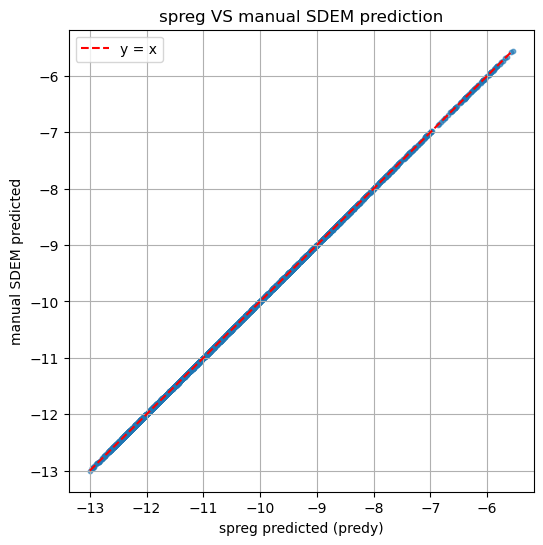

In [13]:
import geopandas as gpd
import numpy as np
from libpysal.weights import DistanceBand, lag_spatial
import matplotlib.pyplot as plt

# -----------------------------
# 1️⃣ 读取 shapefile
# -----------------------------
file = r'E:\seoul\480_based\city2016_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'
gdf = gpd.read_file(file).replace([np.inf, -np.inf], np.nan)

vars_base = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']

# -----------------------------
# 2️⃣ 使用之前训练 SDEM 使用的 w
# -----------------------------
# 如果 w 已经在你模型拟合中创建，就不要重新创建
# 这里只使用同一个 w
w.transform = 'r'

# -----------------------------
# 3️⃣ 创建 WX（空间滞后解释变量）
# -----------------------------
for var in vars_base:
    gdf[f'W_{var}'] = lag_spatial(w, gdf[var])

# -----------------------------
# 4️⃣ 手算 SDEM 预测公式（没有 W_y）
# -----------------------------
gdf['pred_sdem'] = (
    -11.9287
    + -0.0118 * gdf['BCR']
    + 0.0056  * gdf['BHV']
    + -0.3798 * gdf['SVF']
    + 17.4904 * gdf['NDVI']
    + 0.0033  * gdf['EV']
    + 0.0735  * gdf['WR']
    + 0.0882  * gdf['Dist_W']
    + -0.0281 * gdf['Dist_P']
    + 0.1634  * gdf['Dist_M']
    # WX 部分
    + -0.0085 * gdf['W_BCR']
    + -0.0200 * gdf['W_BHV']
    + -1.7936 * gdf['W_SVF']
    + 0.7076  * gdf['W_NDVI']
    + -0.0013 * gdf['W_EV']
    + 0.0096  * gdf['W_WR']
)

# -----------------------------
# 5️⃣ spreg 模型的预测值
# -----------------------------
pred_spreg = models['SDEM'].predy.flatten()

print("predy length:", len(pred_spreg))
print("gdf length:", len(gdf))

# -----------------------------
# 6️⃣ 误差对比
# -----------------------------
gdf['error'] = pred_spreg - gdf['pred_sdem']
rmse = np.sqrt(np.mean(gdf['error'] ** 2))
corr = np.corrcoef(pred_spreg, gdf['pred_sdem'])[0, 1]

print(f"平均误差: {gdf['error'].mean():.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"相关系数: {corr:.6f}")

# -----------------------------
# 7️⃣ 散点图
# -----------------------------
plt.figure(figsize=(6,6))
plt.scatter(pred_spreg, gdf['pred_sdem'], s=10, alpha=0.6)
plt.plot([pred_spreg.min(), pred_spreg.max()],
         [pred_spreg.min(), pred_spreg.max()],
         'r--', label='y = x')
plt.xlabel('spreg predicted (predy)')
plt.ylabel('manual SDEM predicted')
plt.title('spreg VS manual SDEM prediction')
plt.legend()
plt.grid(True)
plt.show()


# 改

c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(


('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')


ValueError: x and y must have same first dimension, but have shapes (100,) and (1, 1861)

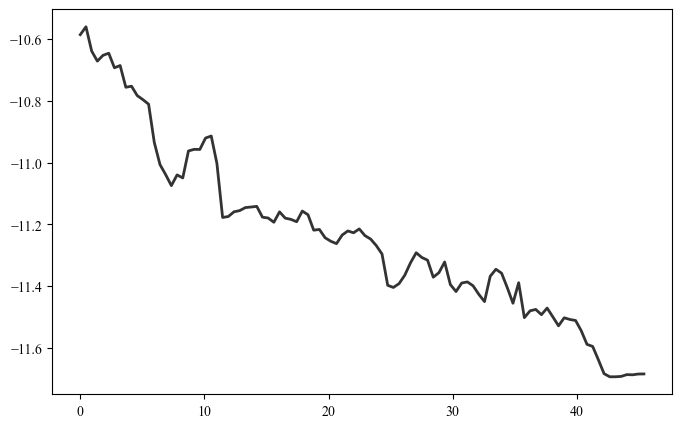

In [66]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import partial_dependence
from libpysal.weights import DistanceBand, lag_spatial
from sklearn.model_selection import train_test_split
# 设置文件夹、变量
grid_folder = r'E:\seoul\480_based'
output_fig_dir = r'E:\seoul\480_based\Machine Learning\figures\nonlinear_predictions_PDP_self'
os.makedirs(output_fig_dir, exist_ok=True)

explanatory_vars_gbdt = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M','X','Y'] # 顺序很讲究
explanatory_vars = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
explanatory_vars_clean = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR']
# explanatory_vars = ['Dist_W', 'Dist_P', 'Dist_M']
# explanatory_vars_clean = []

years = [2016]
y_pred = models['SDM'].predy  # 每个观测点的 SDM 预测
y_base_mean = y_pred.mean()   # 平均预测值

for year in years:
    # 清理后的网格数据
    file  = fr'{grid_folder}\city{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'
    gdf_clean = gpd.read_file(file).replace([np.inf, -np.inf], np.nan)

    # 读取最佳参数
    best_params_file_gbdt = rf'{grid_folder}\Machine Learning\final_GBDT_summary_results.xlsx'
    best_df_gbdt = pd.read_excel(best_params_file_gbdt)
    best_params_file_sdm = rf'{grid_folder}\statistics\SDM_SDEM_all_params.xlsx'
    best_df_sdm = pd.read_excel(best_params_file_sdm)
    best_df_sdm = best_df_sdm[best_df_sdm['Model']=='SDM']

    # 输出文件夹
    output_dir = os.path.join(output_fig_dir, f'{year}')
    os.makedirs(output_dir, exist_ok=True)
    target_folder = best_df_gbdt['Target'].unique()
    # print(target_folder)

    for target in target_folder[2:]:
        hr_targets = [t for t in target_folder if 'hr' in t.lower()]

        # ---------------- HR 合并 ----------------
        for feature in explanatory_vars:
            
            plt.figure(figsize=(8,5))
            for target in hr_targets:
                # gbdt
                row_gbdt = best_df_gbdt[best_df_gbdt['Target']==target].iloc[0]
                params_gbdt = {
                    'learning_rate': row_gbdt['learning_rate'],
                    'max_depth': int(row_gbdt['max_depth']),
                    'n_estimators': int(row_gbdt['n_estimators']),
                    'subsample': row_gbdt['subsample'],
                    'min_samples_split': int(row_gbdt['min_samples_split']),
                    'max_features': float(row_gbdt['max_features']),
                    'random_state': 0
                }

                np.random.seed(0)  # 固定种子以便复现
                random_seeds = np.random.choice(10000, size=20, replace=False)

                X = gdf_clean[explanatory_vars_gbdt]
                y = gdf_clean[target]
                X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = row_gbdt["Random seed"])

                # ----------- PDP 计算部分 -----------
                # GBDT
                model = GradientBoostingRegressor(**params_gbdt)
                model.fit(X_train, y_train)

                X_grid = np.linspace(X[feature].min(), X[feature].max(), 100)
                X_base = pd.DataFrame(np.tile(X.mean(numeric_only=True).values, (100,1)), columns=X.columns) # type: ignore
                X_base[feature] = X_grid

                y_gbdt_pred = model.predict(X_base)

                # SDM
                row_sdm = best_df_sdm[best_df_sdm['Target']==target].iloc[0]
                rho_col = [c for c in row_sdm.index if c.lower() == f"w_{target.lower()}"] #rho_col = ['W_hr_2016']
                rho = float(row_sdm[rho_col[0]]) 

                params_sdm = {
                    'CONSTANT': row_sdm['CONSTANT'],
                    'Wy': rho,
                    'BCR': row_sdm['BCR'],
                    'BHV': row_sdm['BHV'],
                    'SVF': row_sdm['SVF'],
                    'NDVI': row_sdm['NDVI'],
                    'EV': row_sdm['EV'],
                    'WR': row_sdm['WR'],
                    'Dist_W': row_sdm['Dist_W'],
                    'Dist_P': row_sdm['Dist_P'],
                    'Dist_M': row_sdm['Dist_M'],
                    'W_BCR': row_sdm['W_BCR'],
                    'W_BHV': row_sdm['W_BHV'],
                    'W_SVF': row_sdm['W_SVF'],
                    'W_NDVI': row_sdm['W_NDVI'],
                    'W_EV': row_sdm['W_EV'],
                    'W_WR': row_sdm['W_WR']
                }

                # SDM 预测
                data = gdf_clean[explanatory_vars + [target]].dropna()
                data_gdf = gdf_clean.loc[data.index]
                w = DistanceBand.from_dataframe(data_gdf, threshold=1000, binary=False)
                w.transform = 'r'

                W = np.array(w.full()[0])  # 稠密矩阵
                n = W.shape[0] # 1851
                I = np.eye(n)


                constant = np.array([params_sdm.get('CONSTANT', 0)]) 
                beta = np.array([params_sdm.get(var, 0) for var in explanatory_vars])   # (9,)
                theta = np.array([params_sdm.get(f"W_{var}", 0) for var in explanatory_vars_clean])  # (6,)

                # 创建字典
                theta_dict = {f"W_{var}": val for var, val in zip(explanatory_vars_clean, theta)}
                # print(theta_dict)
                rho = params_sdm.get("Wy", 0)
                A_inv = np.linalg.inv(I - rho * W) # (1851,1851)

                X_mean = gdf_clean[explanatory_vars].mean().values  # (9,)
                WX = lag_spatial(w, gdf_clean[explanatory_vars_clean].values) #(1851, 6)
                WX_mean = WX.mean(axis=0)
                feature_idx = explanatory_vars.index(feature)
                

    
                # 基准预测
                X_base_matrix = np.tile(X_mean, (n, 1)) # type: ignore
                WX_mean_matrix = lag_spatial(w, X_base_matrix[:, :len(explanatory_vars_clean)])  # (n,6)
                WX_base_matrix = np.tile(WX_mean.reshape(1, -1), (n, 1))
                y_base = constant + X_base_matrix @ beta + WX_base_matrix @ theta
                y_base = A_inv @ y_base
                y_list = []
                delta_y_list = []

                for val in X_grid:
                    X_temp_matrix = X_base_matrix.copy()
                    X_temp_matrix[:, feature_idx] = val

                    WX_temp_matrix = WX_base_matrix.copy()
                    if feature in explanatory_vars_clean:
                        feature_clean_idx = explanatory_vars_clean.index(feature)
                        WX_temp_matrix[:, feature_clean_idx] = lag_spatial(w, np.full(n, val))
                    
                    y_temp = constant + X_temp_matrix @ beta + WX_temp_matrix @ theta
                    y_temp = A_inv @ y_temp

                    delta_y = y_temp - y_base
                    y_list.append(y_base_mean)

                    delta_y_list.append(delta_y.mean())  # 或者保存每个网格点的 delta_y


                # 转为矩阵并乘上空间效应修正
                y_sdm_pred = y_temp.T # type: ignore # (1851, len(X_grid))
                y_sdm_pred = y_sdm_pred.mean(axis=0)
                
                color_gbdt = '#333333'  # 黑色
                color_sdm = '#555555'  # 黑色虚线
                target_name_map = {
                    'nor_2016': 'Nor_LST',
                    'ext_2016': 'Ext_LST',
                    'hr_2016': 'HR'
                }
                label_name = target_name_map.get(target, target)  # 如果没有在字典里就用原名


                # 绘图
                plt.plot(X_grid, y_gbdt_pred, color=color_gbdt, linewidth=2, label=f'{label_name} GBDT')
                # plt.plot(X_grid, delta_y_list, color=color_gbdt, linewidth=2, label=f'{label_name} GBDT')
                plt.plot(X_grid, y_list, color=color_sdm, linestyle='--', linewidth=2, label=f'{label_name} SDM')

            ax = plt.gca()  # 获取当前坐标轴
            percentiles = np.percentile(X[feature], np.linspace(10, 90, 9))  # 0%,10%,...,100%
            rug_height = 0.05  # 画布坐标高度（0~1）

            for p in percentiles:
                ax.plot([p, p], [0, rug_height], color='black', linewidth=1.2, transform=ax.get_xaxis_transform())

            # 设置全局字体为 Times New Roman
            plt.rcParams["font.family"] = "Times New Roman"

            plt.xlabel(feature, fontsize=16)
            plt.ylabel('Temperature (℃)', fontsize=16)
            plt.xticks(fontsize=12)
            plt.yticks(fontsize=12)
            plt.grid(False)
            plt.legend(loc='upper right', frameon=False, fontsize=12)
            plt.xlim(X[feature].min(), X[feature].max())
             
            plt.ylim(-15,-1)
            plt.tight_layout()
            plt.savefig(os.path.join(output_dir, f'{feature}_hr_{year}_comparison.png'), dpi=300)
            plt.close()
            print(f"✅ Saved {feature}_hr_{year}_comparison.png")

# SDEM 的base值作为参考

In [29]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import partial_dependence
from libpysal.weights import DistanceBand, lag_spatial
from sklearn.model_selection import train_test_split
# 设置文件夹、变量
grid_folder = r'E:\seoul\480_based'
output_fig_dir = r'E:\seoul\480_based\Machine Learning\figures\nonlinear_predictions_PDP_self_11111111111'
os.makedirs(output_fig_dir, exist_ok=True)

explanatory_vars_gbdt = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M','X','Y'] # 顺序很讲究
explanatory_vars = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
explanatory_vars_clean = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR']

years = [2016]

for year in years:
    # 清理后的网格数据
    file  = fr'{grid_folder}\city{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'
    gdf_clean = gpd.read_file(file).replace([np.inf, -np.inf], np.nan)

    # 读取最佳参数
    best_params_file_gbdt = rf'{grid_folder}\Machine Learning\final_GBDT_summary_results.xlsx'
    best_df_gbdt = pd.read_excel(best_params_file_gbdt)
    best_params_file_sdem = rf'{grid_folder}\statistics\SDM_SDEM_all_params.xlsx'
    best_df_sdem = pd.read_excel(best_params_file_sdem)
    best_df_sdem = best_df_sdem[best_df_sdem['Model']=='SDEM']

    # 输出文件夹
    output_dir = os.path.join(output_fig_dir, f'{year}')
    os.makedirs(output_dir, exist_ok=True)
    target_folder = best_df_gbdt['Target'].unique()
    # print(target_folder)

    for target in target_folder[2:]:
        hr_targets = [t for t in target_folder if 'hr' in t.lower()]

        # ---------------- EXT + NOR 合并 ----------------
        for feature in explanatory_vars:
            plt.figure(figsize=(8,5))
            for target in hr_targets:
                # gbdt
                row_gbdt = best_df_gbdt[best_df_gbdt['Target']==target].iloc[0]
                params_gbdt = {
                    'learning_rate': row_gbdt['learning_rate'],
                    'max_depth': int(row_gbdt['max_depth']),
                    'n_estimators': int(row_gbdt['n_estimators']),
                    'subsample': row_gbdt['subsample'],
                    'min_samples_split': int(row_gbdt['min_samples_split']),
                    'max_features': float(row_gbdt['max_features']),
                    'random_state': 0
                }

                np.random.seed(0)  # 固定种子以便复现
                random_seeds = np.random.choice(10000, size=20, replace=False)

                X = gdf_clean[explanatory_vars_gbdt]
                y = gdf_clean[target]
                X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = row_gbdt["Random seed"])

                # ----------- PDP 计算部分 -----------
                model = GradientBoostingRegressor(**params_gbdt)
                model.fit(X_train, y_train)

                X_grid = np.linspace(X[feature].min(), X[feature].max(), 100)
                X_base = pd.DataFrame(np.tile(X.mean(numeric_only=True).values, (100,1)), columns=X.columns)
                X_base[feature] = X_grid

                y_gbdt_pred = model.predict(X_base)

                # SDEM
                row_sdem = best_df_sdem[best_df_sdem['Target']==target].iloc[0]
                params_sdem = {
                    'CONSTANT': row_sdem['CONSTANT'],
                    'BCR': row_sdem['BCR'],
                    'BHV': row_sdem['BHV'],
                    'SVF': row_sdem['SVF'],
                    'NDVI': row_sdem['NDVI'],
                    'EV': row_sdem['EV'],
                    'WR': row_sdem['WR'],
                    'Dist_W': row_sdem['Dist_W'],
                    'Dist_P': row_sdem['Dist_P'],
                    'Dist_M': row_sdem['Dist_M'],
                    'W_BCR': row_sdem['W_BCR'],
                    'W_BHV': row_sdem['W_BHV'],
                    'W_SVF': row_sdem['W_SVF'],
                    'W_NDVI': row_sdem['W_NDVI'],
                    'W_EV': row_sdem['W_EV'],
                    'W_WR': row_sdem['W_WR'],
                    'lambda': row_sdem['lambda']
                }

                # SDEM 预测
                X_mean = gdf_clean[explanatory_vars].mean().to_dict()
                w = DistanceBand.from_dataframe(gdf_clean, threshold=1000, binary=False)
                w.transform = 'r'
                WX = lag_spatial(w, gdf_clean[explanatory_vars_clean].values)
                WX_mean = pd.Series(WX.mean(axis=0), index=[f"W_{v}" for v in explanatory_vars_clean])
                # y_base：平均值预测
                all_vars_base = {'CONSTANT': 1.0, **X_mean, **WX_mean.to_dict()}
                y_base = sum(params_sdem[var] * all_vars_base.get(var, 0) for var in params_sdem if var != 'lambda')
                y_base_array = np.full_like(X_grid, y_base, dtype=float)
                y_sdem_pred = []
                for val in X_grid:
                    X_temp = X_mean.copy()
                    X_temp[feature] = val
                    WX_temp = WX_mean.copy()
                    if feature in explanatory_vars_clean:
                        WX_temp[feature] = pd.Series(val, index=[f"W_{feature}"])

                    all_vars = {'CONSTANT': 1.0, **X_temp, **WX_temp.to_dict()}
                    y_pred = 0
                    for var, coef in params_sdem.items():
                        if var != 'lambda':
                            y_pred += coef * all_vars.get(var, 0)
                    y_sdem_pred.append(y_pred)
                    
                y_sdem_pred = np.array(y_sdem_pred)


                color_gbdt = '#333333'  # 黑色
                color_sdm = '#555555'  # 黑色虚线

                # 命名规范映射
                target_name_map = {
                    'nor_2016': 'Nor_LST',
                    'ext_2016': 'Ext_LST',
                    'hr_2016': 'HR'
                }
                label_name = target_name_map.get(target, target)  # 如果没有在字典里就用原名


                # 绘图
                plt.plot(X_grid, y_gbdt_pred, color=color_gbdt, linewidth=2, label=f'{label_name} GBDT')
                plt.plot(X_grid, y_base_array, color=color_gbdt, linewidth=2, label=f'{label_name} mean base')
                plt.plot(X_grid, y_sdem_pred, color=color_sdm, linestyle='--', linewidth=2, label=f'{label_name} SDEM')

            ax = plt.gca()  # 获取当前坐标轴
            percentiles = np.percentile(X[feature], np.linspace(10, 90, 9))  # 0%,10%,...,100%
            rug_height = 0.05  # 画布坐标高度（0~1）

            for p in percentiles:
                ax.plot([p, p], [0, rug_height], color='black', linewidth=1.2, transform=ax.get_xaxis_transform())

            # 设置全局字体为 Times New Roman
            plt.rcParams["font.family"] = "Times New Roman"

            plt.xlabel(feature, fontsize=16)
            plt.ylabel('Temperature (℃)', fontsize=16)
            plt.xticks(fontsize=12)
            plt.yticks(fontsize=12)
            plt.grid(False)
            plt.legend(loc='upper right', frameon=False, fontsize=12)
            plt.margins(x=0)  # 去掉x方向留白
             
             
             
            plt.ylim(-15,-1)
            plt.tight_layout()
            plt.savefig(os.path.join(output_dir, f'{feature}_hr_{year}_comparison.png'), dpi=300)
            plt.close()
            print(f"✅ Saved {feature}_hr_{year}_comparison.png")

c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(


('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')
✅ Saved BCR_hr_2016_comparison.png


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(


('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')
✅ Saved BHV_hr_2016_comparison.png


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(


...

('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')
✅ Saved Dist_W_hr_2016_comparison.png


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(


('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')
✅ Saved Dist_P_hr_2016_comparison.png


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(


('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')
✅ Saved Dist_M_hr_2016_comparison.png
